<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Benchmark 1 - TPeanuts vs Legacy Peanuts Performance
---

This notebook measures wall-clock performance for the torch-native `tpeanuts` implementation against the bundled legacy `peanuts` implementation. The benchmark covers vacuum propagation, solar production, Earth matter propagation, exposure-style angular integration, the solar-to-detector chain, and a conditional GPU comparison when CUDA is available.

The purpose is performance characterization, not precision validation. Precision and bit-level compatibility are studied in the validation notebooks; here the same physical inputs are used so timing differences can be interpreted as implementation and batching effects.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: timing methodology, vectorization, legacy reference, and benchmark observables |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - paths, parameters, shared objects and helpers |
| [3](#3.-Vacuum-Propagation) | **Vacuum Propagation** |
| [4](#4.-Solar-Production) | **Solar Production** |
| [5](#5.-Earth-Propagation) | **Earth Propagation** |
| [6](#6.-Integrated-Probabilities) | **Integrated Probabilities** |
| [7](#7.-Solar-to-Detector-Chain) | **Solar-to-Detector Chain** |
| [8](#8.-GPU-Benchmark) | **GPU Benchmark** |
| [9](#9.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Performance Benchmarking Strategy

This notebook compares two implementations of the same neutrino-oscillation workflows: the torch-native `tpeanuts` API and the legacy NumPy/Numba `peanuts` routines. The measured quantity is wall-clock execution time for fixed input grids. Each benchmark is executed after warm-up calls and repeated several times; the reported speedup is

$$S = \frac{t_\mathrm{legacy}}{t_\mathrm{tpeanuts}},$$

so that $S>1$ means `tpeanuts` is faster than the legacy reference.

---

### 0.2 Vectorization and Grid Scaling

The torch implementation is designed to evaluate many energies and nadir angles in batched tensor operations. The benchmark therefore scans energy-grid size $N_E$ and, for Earth-dependent workflows, nadir-grid size $N_\eta$. Log-log timing slopes provide a compact diagnostic of algorithmic scaling,

$$t(N) \propto N^p,$$

where the fitted exponent $p$ distinguishes roughly linear scaling from larger overheads.

---

### 0.3 Physics Workflows Benchmarked

The benchmark covers the main observable layers used in the project:

| Workflow | Observable |
|----------|------------|
| Vacuum propagation | flavour-transition matrix and incoherent flux contraction |
| Solar production | adiabatic solar flavour probabilities and mass-basis source weights |
| Earth propagation | mass-basis Earth regeneration over energy-nadir grids |
| Integrated probabilities | nadir-averaged probabilities with a simple exposure weight |
| Solar-to-detector chain | solar mass weights followed by Earth propagation |

The Hamiltonians and probability definitions follow the standard three-flavour oscillation framework in vacuum and matter, with matter effects described by the Wolfenstein charged-current potential.

---

### 0.4 Legacy Reference and Precision Mode

The legacy `peanuts` implementation is scalar and loop-based for many workflows, while `tpeanuts` exposes batched tensor APIs. The optional `legacy_precision` flag in solar and matter calculations reproduces rounded constants used by the legacy code when numerical agreement is the goal. In this performance notebook, the flag is configurable but the main observable is runtime.

---

**References**

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, *Resonance amplification of oscillations in matter*, Sov. J. Nucl. Phys. **42**, 913 (1985).
- I. Esteban et al., *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*, JHEP **09**, 178 (2022).
- C. R. Harris et al., *Array programming with NumPy*, Nature **585**, 357 (2020).
- A. Paszke et al., *PyTorch: An Imperative Style, High-Performance Deep Learning Library*, NeurIPS (2019).

## 1. Libraries

In [1]:
from __future__ import annotations

import gc
import math
import time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass
from tpeanuts.medium.solar.profile import SolarParameters, SolarProfile
from tpeanuts.medium.solar.validation import legacy_modules
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition

from peanuts.earth import Pearth as legacy_pearth
from peanuts.earth import earthdensity as LegacyEarthDensity
from peanuts.pmns import PMNS as LegacyPMNS
from peanuts.vacuum import Pvacuum as legacy_pvacuum


print(f"Torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
from tpeanuts.util.math import numpy_trapezoid


Warning!: Python module pyslha not found, disabling slha reading routines
Torch version : 2.3.1
CUDA available: True


## 2. Paths and Configuration

This section resolves the project paths, creates the benchmark output directory, and fixes the physical and numerical configuration used in the timing study.

### 2.1 Paths

`load_notebook_config()` resolves the project root, applies the shared notebook style, and creates the output directory. Following the project notebook convention, outputs from this notebook are saved under `benchmark/`, which is the relative notebook path below `notebooks/` without the notebook filename.

**Expected results:** the printed paths should point to the package root, the bundled legacy data directory, the explicit TPeanuts solar CSV files, and the benchmark output directory used by all CSV files and figures.

In [2]:
config = load_notebook_config()

PACKAGE_DIR = config.package_dir
OUTPUT_ROOT = config.output_root

OUTPUT_DATA_ROOT       = config.output_data_root
OUTPUT_ANALYSIS_ROOT   = config.output_analysis_root
OUTPUT_BENCHMARK_ROOT  = config.output_benchmark_root

OUTPUT_DIR = config.output_dir("benchmark")

DATA_DIR        = config.data_dir
LEGACY_DATA_DIR = config.legacy_data_dir

EARTH_DENSITY_TPEANUTS = str(DATA_DIR / "earth" / "prem" / "fit" / "even_power_electron.csv")
EARTH_DENSITY_LEGACY   = str(LEGACY_DATA_DIR / "earth_density.csv")
SOLAR_MODEL_FILE = str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat")
SOLAR_FLUX_FILE = str(LEGACY_DATA_DIR / "fluxes_b16.dat")
SOLAR_DENSITY_CSV_FILE = str(DATA_DIR / "solar" / "bahcall" / "density" / "bp2000_density_electron_neutron_monotonic.csv")
SOLAR_FLUX_CSV_FILE = str(DATA_DIR / "solar" / "bahcall" / "flux" / "fluxes_bahcall_bp2004.csv")
SPECTRUM_FILES = {
    "8B":         str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
    "hep":        str(LEGACY_DATA_DIR / "hep_shape.csv"),
    "pp":         str(LEGACY_DATA_DIR / "pp_shape.csv"),
    "17F":        str(LEGACY_DATA_DIR / "f17_shape.csv"),
    "7Beground":  str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
    "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
    "13N":        str(LEGACY_DATA_DIR / "n13_shape.csv"),
    "15O":        str(LEGACY_DATA_DIR / "o15_shape.csv"),
}

print(f"PACKAGE_DIR = {PACKAGE_DIR}")
print("Legacy Data Dir :", LEGACY_DATA_DIR)
print("Torch solar model:", SOLAR_DENSITY_CSV_FILE)
print("Torch solar flux :", SOLAR_FLUX_CSV_FILE)
print("Output directory:", OUTPUT_DIR)


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Legacy Data Dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Torch solar model: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\nudistr_b16_agss09.csv
Torch solar flux : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\fluxes_b16.csv
Output directory: v:\output\benchmark


### 2.2 Configuration

This section defines the physical inputs and timing controls used by the benchmark. The oscillation parameters are loaded from the project preset, the Earth and solar density files are fixed explicitly, and the benchmark grids control the computational load.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | default `oscillation_parameters_from_preset` | Three-flavour NuFIT-style benchmark point |
| Vacuum baseline | 1300 km | Long-baseline reference distance |
| Solar source | `8B` | Source used for solar production benchmarks |
| Earth profile | bundled `even_power_electron.csv` | Five-layer perturbative Earth propagation profile |
| Solar profile | bundled B16 AGSS09 CSV | TPeanuts solar density and production profile |
| Legacy profile | bundled `data/peanuts` files | Legacy `peanuts` reference data |
| Energy grid sizes | 4 to 1024 | Scaling axis for all workflows |
| Nadir grid sizes | 4 to 256 | Scaling axis for Earth-dependent workflows |
| Timing repeats/warmups | configurable below | Warm-up removes first-call/JIT effects from timing |

**Expected results:** the configuration cell should print the active repeat/warm-up counts and build one consistent set of oscillation parameters for both implementations.

In [3]:
DEVICE = config.device
DTYPE  = config.dtype
SHOW_PLOTS = config.show_plots
GPU_DEVICE = torch.device("cuda", 0) if torch.cuda.is_available() else None

context     = RuntimeContext.resolve(DEVICE, DTYPE)
oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)
pmns        = oscillation.pmns
THETA12  = float(pmns.params.theta12.detach().cpu())
THETA13  = float(pmns.params.theta13.detach().cpu())
THETA23  = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())
legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)

ENERGY_GRID_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
NADIR_GRID_SIZES  = [4, 8, 16, 32, 64, 128, 256]
EARTH_METHOD_COMPARISON_ENERGY_SIZES = [8, 32, 64]
EARTH_METHOD_COMPARISON_NADIR_SIZES = [8, 32, 64]

# More repeats/warmups for stable timing and proper Numba JIT warm-up
TIMING_REPEATS = 5   # was 2 — minimum for reliable min/mean
TIMING_WARMUPS = 3   # was 1 — ensures Numba JIT compiles before timing

EARTH_METHOD          = "analytical"   # "analytical" or "numerical"
LEGACY_EARTH_MODE     = EARTH_METHOD
EARTH_NUMERICAL_STEPS = 160
EARTH_ODE_METHOD      = "midpoint"

EARTH_DEPTH_M          = 0.0
SOLAR_DETECTOR_DEPTH_M = 1000.0
SOLAR_SOURCE           = "8B"
VACUUM_BASELINE_KM     = 1300.0

# Solar matter-mixing precision mode (see benchmark0_tpeanuts_vs_peanuts_precision.ipynb,
# Section 4.4, for the diagnosis): False (default) evaluates Vk/th12_M/th13_M
# from full-precision physical constants; True switches to the legacy peanuts
# combined Vk prefactor (3.868e-7 / 2.533, each hardcoded to 4 significant
# digits there). Only affects numerical agreement with legacy, not timing.
SOLAR_LEGACY_PRECISION = False

MASS_WEIGHTS    = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)
MASS_WEIGHTS_NP = np.array([0.20, 0.30, 0.50], dtype=np.float64)

print("Performance benchmark parameters loaded.")
print(f"  TIMING_REPEATS = {TIMING_REPEATS},  TIMING_WARMUPS = {TIMING_WARMUPS}")


Performance benchmark parameters loaded.
  TIMING_REPEATS = 5,  TIMING_WARMUPS = 3


The following cell builds the shared Earth and solar model objects used by the benchmark. TPeanuts uses the current `EarthProfile`, `EarthParameters`, `SolarProfile`, and `SolarParameters` APIs, while the legacy side uses the bundled `peanuts` objects.

**Expected results:** both TPeanuts and legacy density/solar models should load successfully before any timing loop starts.

In [4]:
earth_profile_t = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_TPEANUTS, "tabulated_density": False},
    ),
    context=context,
)
earth_density_l = LegacyEarthDensity(density_file=EARTH_DENSITY_LEGACY, tabulated_density=False)
solar_profile = SolarProfile.default(
    params=SolarParameters(
        density_path=SOLAR_DENSITY_CSV_FILE,
        fluxes_path=SOLAR_FLUX_CSV_FILE,
    ),
    context=context,
)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=SOLAR_MODEL_FILE,
    flux_file=SOLAR_FLUX_FILE,
    spectrum_files=SPECTRUM_FILES,
)
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)
print("Shared density and solar models loaded.")


Shared density and solar models loaded.


### 2.3 Local Helpers

The helper functions below keep repeated benchmark mechanics in one place: grid construction, timing loops, plotting, legacy wrappers, and small pipeline wrappers for solar, Earth, and solar-to-detector workflows. They are local to this notebook because they combine benchmark-specific timing logic with several physical modules.

**Expected results:** this cell should only define functions and print a confirmation message; no benchmark timing is performed yet.

In [5]:
from tpeanuts.notebooks.benchmark.benchmark_helpers import *

configure_benchmark_helpers(globals(), backend="legacy")
print("Benchmark helpers imported from notebooks/benchmark/benchmark_helpers.py.")


Helpers defined.


## 3. Vacuum Propagation

This section benchmarks vacuum flavour-transition probabilities and a synthetic incoherent flux contraction. The TPeanuts path uses the batched `vacuum_probability_transition` API, while the legacy path loops over `peanuts.vacuum.Pvacuum`.

**Expected results:** the probability and flux timings should scale primarily with energy-grid size. TPeanuts is expected to benefit from batched tensor evaluation as the grid grows.

### 3.1 Probability Timing

The output table stores best, mean, and standard-deviation timings for each energy-grid size. The plot shows absolute timing and the fitted log-log scaling slope.

**Expected results:** both implementations should return finite timings; the speedup curve should reveal where tensor batching overtakes scalar legacy loops.

vacuum probabilities               | NE=   4 | Neta=None | t=1.2654e-03s±5.9e-05 | leg=7.6520e-04s | x0.60
vacuum probabilities               | NE=   8 | Neta=None | t=1.2460e-03s±1.7e-04 | leg=1.2936e-03s | x1.04
vacuum probabilities               | NE=  16 | Neta=None | t=1.2602e-03s±1.1e-04 | leg=2.3347e-03s | x1.85
vacuum probabilities               | NE=  32 | Neta=None | t=1.2766e-03s±8.0e-05 | leg=4.4722e-03s | x3.50
vacuum probabilities               | NE=  64 | Neta=None | t=1.3161e-03s±3.7e-04 | leg=8.5991e-03s | x6.53
vacuum probabilities               | NE= 128 | Neta=None | t=1.3329e-03s±2.9e-04 | leg=1.6932e-02s | x12.70
vacuum probabilities               | NE= 256 | Neta=None | t=1.3943e-03s±2.4e-04 | leg=3.3600e-02s | x24.10
vacuum probabilities               | NE= 512 | Neta=None | t=1.6180e-03s±2.3e-04 | leg=6.7481e-02s | x41.71
vacuum probabilities               | NE=1024 | Neta=None | t=2.1662e-03s±1.7e-04 | leg=1.3389e-01s | x61.81


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum probabilities,4,None,0.001265,0.000765,0.001323,0.000792,0.000059,0.000028,0.604710
1,vacuum probabilities,8,None,0.001246,0.001294,0.001421,0.001312,0.000167,0.000012,1.038202
2,vacuum probabilities,16,None,0.001260,0.002335,0.001364,0.002376,0.000109,0.000026,1.852643
3,vacuum probabilities,32,None,0.001277,0.004472,0.001333,0.005024,0.000080,0.000429,3.503212
4,vacuum probabilities,64,None,0.001316,0.008599,0.001640,0.008790,0.000369,0.000218,6.533774
5,vacuum probabilities,128,None,0.001333,0.016932,0.001605,0.017091,0.000291,0.000121,12.703428
6,vacuum probabilities,256,None,0.001394,0.033600,0.001694,0.034128,0.000242,0.000303,24.098115
7,vacuum probabilities,512,None,0.001618,0.067481,0.001865,0.067854,0.000235,0.000223,41.706243
8,vacuum probabilities,1024,None,0.002166,0.133891,0.002330,0.137514,0.000175,0.003246,61.809021


Saved: v:\output\benchmark\vacuum_probability_timing.csv


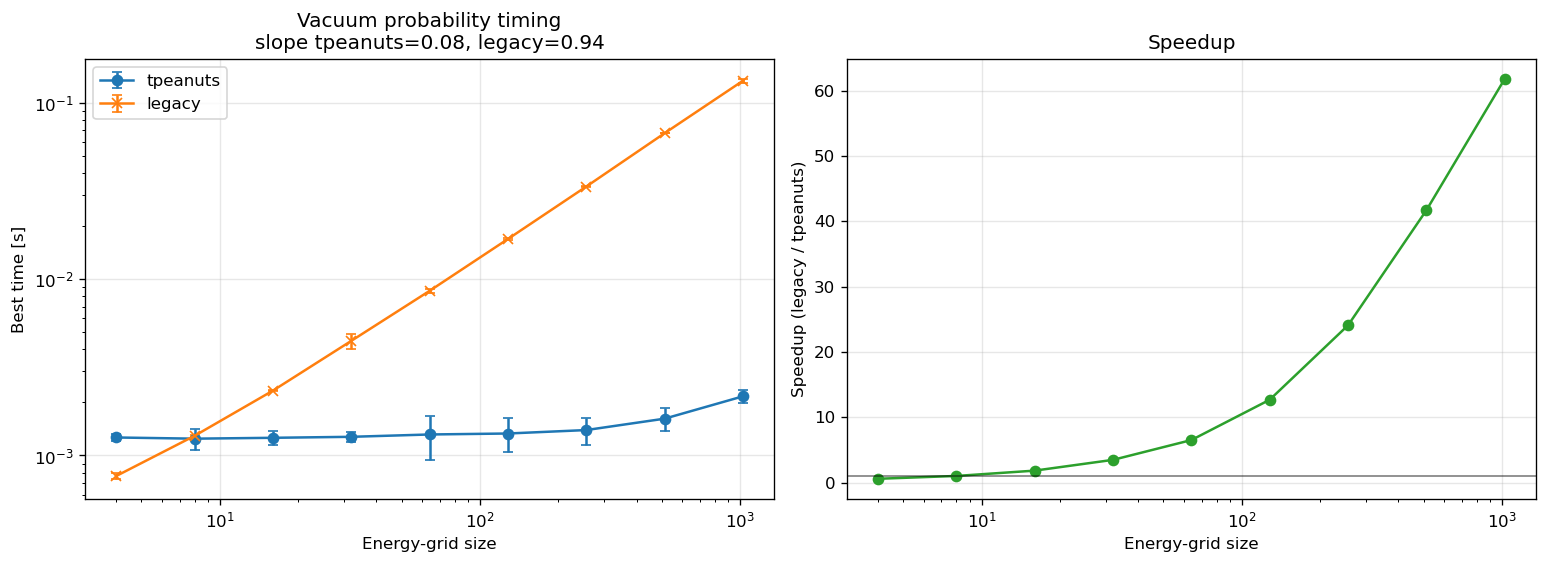

v:\output\benchmark\vacuum_probability_timing.png


In [6]:
vacuum_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    vacuum_probability_records.append(benchmark_pair(
        "vacuum probabilities", ne, None,
        lambda E=E: vacuum_probability_transition(oscillation, E, VACUUM_BASELINE_KM, context=context),
        lambda E=E: legacy_vacuum_matrix(E, VACUUM_BASELINE_KM),
    ))
vacuum_probability_df = pd.DataFrame(vacuum_probability_records)
display(vacuum_probability_df)
save_results(vacuum_probability_df, "vacuum_probability_timing")
plot_energy_scaling(vacuum_probability_df, "Vacuum probability timing", "vacuum_probability_timing.png")

### 3.2 Flux Timing

This benchmark applies the vacuum probability matrix to a synthetic three-flavour flux vector.

**Expected results:** the flux timing should follow the probability timing plus a small matrix-vector contraction overhead.

vacuum flux                        | NE=   4 | Neta=None | t=1.3721e-03s±4.4e-05 | leg=7.7130e-04s | x0.56
vacuum flux                        | NE=   8 | Neta=None | t=1.3765e-03s±8.5e-05 | leg=1.2930e-03s | x0.94
vacuum flux                        | NE=  16 | Neta=None | t=1.4009e-03s±1.8e-04 | leg=2.3468e-03s | x1.68
vacuum flux                        | NE=  32 | Neta=None | t=1.3987e-03s±1.4e-04 | leg=4.3800e-03s | x3.13
vacuum flux                        | NE=  64 | Neta=None | t=1.4603e-03s±4.3e-04 | leg=8.6125e-03s | x5.90
vacuum flux                        | NE= 128 | Neta=None | t=1.4852e-03s±4.1e-04 | leg=1.6921e-02s | x11.39
vacuum flux                        | NE= 256 | Neta=None | t=1.5827e-03s±2.5e-04 | leg=3.3614e-02s | x21.24
vacuum flux                        | NE= 512 | Neta=None | t=1.7588e-03s±2.7e-04 | leg=6.7554e-02s | x38.41
vacuum flux                        | NE=1024 | Neta=None | t=2.2146e-03s±2.3e-04 | leg=1.3367e-01s | x60.36


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum flux,4,None,0.001372,0.000771,0.001401,0.000785,0.000044,0.000010,0.562131
1,vacuum flux,8,None,0.001377,0.001293,0.001463,0.001310,0.000085,0.000012,0.939339
2,vacuum flux,16,None,0.001401,0.002347,0.001509,0.002366,0.000178,0.000019,1.675209
3,vacuum flux,32,None,0.001399,0.004380,0.001509,0.004653,0.000138,0.000263,3.131479
4,vacuum flux,64,None,0.001460,0.008612,0.001939,0.008843,0.000435,0.000409,5.897761
5,vacuum flux,128,None,0.001485,0.016921,0.002017,0.017075,0.000407,0.000121,11.393214
6,vacuum flux,256,None,0.001583,0.033614,0.002011,0.034071,0.000247,0.000587,21.238328
7,vacuum flux,512,None,0.001759,0.067554,0.002020,0.068552,0.000272,0.001117,38.409256
8,vacuum flux,1024,None,0.002215,0.133668,0.002465,0.138636,0.000227,0.002758,60.357763


Saved: v:\output\benchmark\vacuum_flux_timing.csv


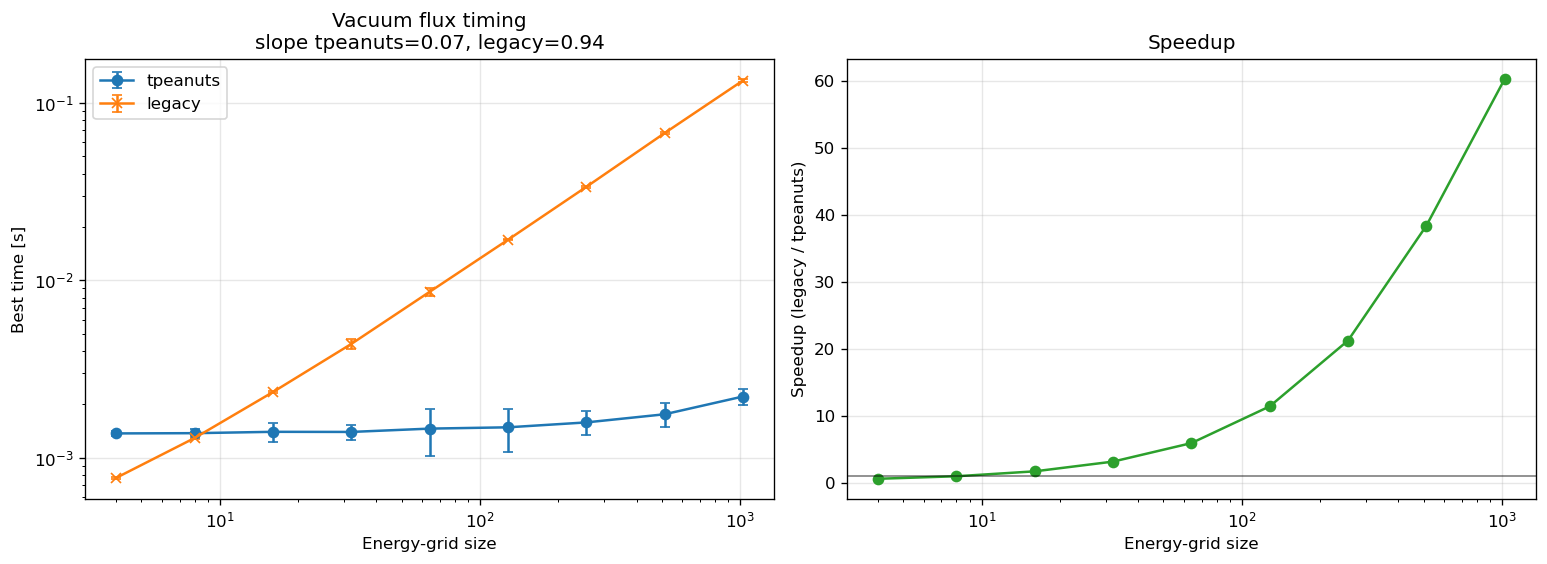

v:\output\benchmark\vacuum_flux_timing.png


In [7]:
vacuum_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    flux_t = synthetic_flux(E)
    flux_l = to_numpy(flux_t)
    vacuum_flux_records.append(benchmark_pair(
        "vacuum flux", ne, None,
        lambda E=E, ft=flux_t: probability_incoherent(
            vacuum_probability_transition(oscillation, E, VACUUM_BASELINE_KM, context=context), ft),
        lambda E=E, fl=flux_l: np.einsum("eba,ea->eb", legacy_vacuum_matrix(E, VACUUM_BASELINE_KM), fl),
    ))
vacuum_flux_df = pd.DataFrame(vacuum_flux_records)
display(vacuum_flux_df)
save_results(vacuum_flux_df, "vacuum_flux_timing")
plot_energy_scaling(vacuum_flux_df, "Vacuum flux timing", "vacuum_flux_timing.png")

## 4. Solar Production

This section benchmarks solar production probabilities and mass-basis source weights for the selected solar source. `SOLAR_LEGACY_PRECISION` controls the matter-mixing prefactor used by `solar_probability_state` and `solar_probability_mass`; it affects numerical compatibility with legacy constants, not the benchmark structure.

**Expected results:** TPeanuts should evaluate the full energy grid in one tensor call, while legacy solar probabilities are computed by scalar loops over energy.

### 4.1 Probability Timing

The benchmark compares `solar_probability_state` against legacy `Psolar` over increasing energy-grid sizes.

**Expected results:** timing should increase with grid size, and vectorized TPeanuts evaluation should reduce Python-loop overhead.

solar probabilities                | NE=   4 | Neta=None | t=3.9599e-03s±1.2e-04 | leg=7.9690e-04s | x0.20
solar probabilities                | NE=   8 | Neta=None | t=4.7849e-03s±3.5e-04 | leg=1.3625e-03s | x0.28
solar probabilities                | NE=  16 | Neta=None | t=6.0316e-03s±6.0e-04 | leg=2.4782e-03s | x0.41
solar probabilities                | NE=  32 | Neta=None | t=8.4583e-03s±3.1e-04 | leg=4.6624e-03s | x0.55
solar probabilities                | NE=  64 | Neta=None | t=1.1618e-02s±5.4e-04 | leg=9.2993e-03s | x0.80
solar probabilities                | NE= 128 | Neta=None | t=1.5343e-02s±2.8e-02 | leg=1.8424e-02s | x1.20
solar probabilities                | NE= 256 | Neta=None | t=2.1450e-02s±7.4e-04 | leg=3.6748e-02s | x1.71
solar probabilities                | NE= 512 | Neta=None | t=4.8214e-02s±3.4e-03 | leg=7.1101e-02s | x1.47
solar probabilities                | NE=1024 | Neta=None | t=1.0387e-01s±6.2e-03 | leg=1.4107e-01s | x1.36


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar probabilities,4,None,0.003960,0.000797,0.004157,0.000883,0.000123,0.000075,0.201242
1,solar probabilities,8,None,0.004785,0.001363,0.005267,0.001560,0.000354,0.000327,0.284750
2,solar probabilities,16,None,0.006032,0.002478,0.006941,0.002629,0.000601,0.000113,0.410869
3,solar probabilities,32,None,0.008458,0.004662,0.008766,0.004773,0.000314,0.000128,0.551222
4,solar probabilities,64,None,0.011618,0.009299,0.012408,0.009385,0.000539,0.000068,0.800436
5,solar probabilities,128,None,0.015343,0.018424,0.040318,0.018596,0.027670,0.000218,1.200759
6,solar probabilities,256,None,0.021450,0.036748,0.022664,0.038141,0.000737,0.001362,1.713151
7,solar probabilities,512,None,0.048214,0.071101,0.051721,0.074804,0.003423,0.002081,1.474697
8,solar probabilities,1024,None,0.103869,0.141071,0.109523,0.145686,0.006198,0.002787,1.358165


Saved: v:\output\benchmark\solar_probability_timing.csv


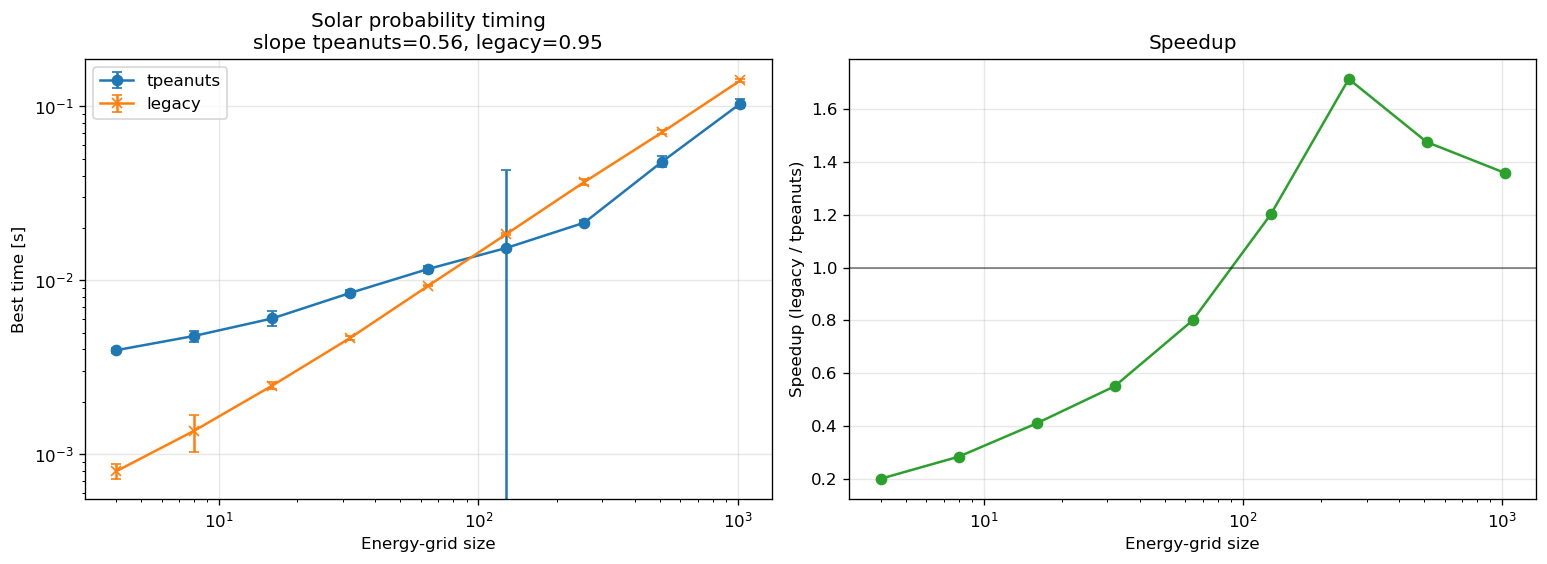

v:\output\benchmark\solar_probability_timing.png


In [8]:
solar_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    solar_probability_records.append(benchmark_pair(
        "solar probabilities", ne, None,
        lambda E=E: solar_probability_state(oscillation, E, solar_profile, SOLAR_SOURCE,
                            legacy_precision=SOLAR_LEGACY_PRECISION),
        lambda E=E: np.stack([
            legacy_solar_module.Psolar(legacy_pmns_solar, DM21_EV2, DM3L_EV2, float(e),
                                       legacy_model.radius(), legacy_model.density(),
                                       legacy_model.fraction(SOLAR_SOURCE))
            for e in to_numpy(E)
        ]),
    ))
solar_probability_df = pd.DataFrame(solar_probability_records)
display(solar_probability_df)
save_results(solar_probability_df, "solar_probability_timing")
plot_energy_scaling(solar_probability_df, "Solar probability timing", "solar_probability_timing.png")

### 4.2 Flux Timing

This benchmark applies a simple source-spectrum weight to the solar mass-basis probabilities.

**Expected results:** timing should be close to the solar mass-probability timing because the spectrum multiplication is inexpensive.

solar flux                         | NE=   4 | Neta=None | t=3.0870e-03s±3.6e-04 | leg=7.1140e-04s | x0.23
solar flux                         | NE=   8 | Neta=None | t=3.8638e-03s±3.1e-04 | leg=1.2195e-03s | x0.32
solar flux                         | NE=  16 | Neta=None | t=5.1989e-03s±4.1e-04 | leg=2.1855e-03s | x0.42
solar flux                         | NE=  32 | Neta=None | t=8.2378e-03s±4.5e-03 | leg=4.1648e-03s | x0.51
solar flux                         | NE=  64 | Neta=None | t=1.0783e-02s±9.2e-04 | leg=8.1995e-03s | x0.76
solar flux                         | NE= 128 | Neta=None | t=1.3275e-02s±2.8e-03 | leg=1.6110e-02s | x1.21
solar flux                         | NE= 256 | Neta=None | t=2.2245e-02s±1.8e-03 | leg=3.2444e-02s | x1.46
solar flux                         | NE= 512 | Neta=None | t=4.4563e-02s±2.8e-02 | leg=6.5880e-02s | x1.48
solar flux                         | NE=1024 | Neta=None | t=1.1009e-01s±4.0e-03 | leg=1.2853e-01s | x1.17


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar flux,4,None,0.003087,0.000711,0.003395,0.000738,0.000359,0.000021,0.230450
1,solar flux,8,None,0.003864,0.001219,0.004207,0.001229,0.000307,0.000015,0.315622
2,solar flux,16,None,0.005199,0.002185,0.005578,0.002229,0.000412,0.000025,0.420377
3,solar flux,32,None,0.008238,0.004165,0.016214,0.004847,0.004524,0.000645,0.505572
4,solar flux,64,None,0.010783,0.008200,0.011748,0.008252,0.000918,0.000048,0.760410
5,solar flux,128,None,0.013275,0.016110,0.016882,0.016974,0.002774,0.000637,1.213537
6,solar flux,256,None,0.022245,0.032444,0.023633,0.034055,0.001767,0.001945,1.458436
7,solar flux,512,None,0.044563,0.065880,0.060612,0.070413,0.027583,0.006404,1.478360
8,solar flux,1024,None,0.110088,0.128529,0.112576,0.129039,0.003992,0.000381,1.167513


Saved: v:\output\benchmark\solar_flux_timing.csv


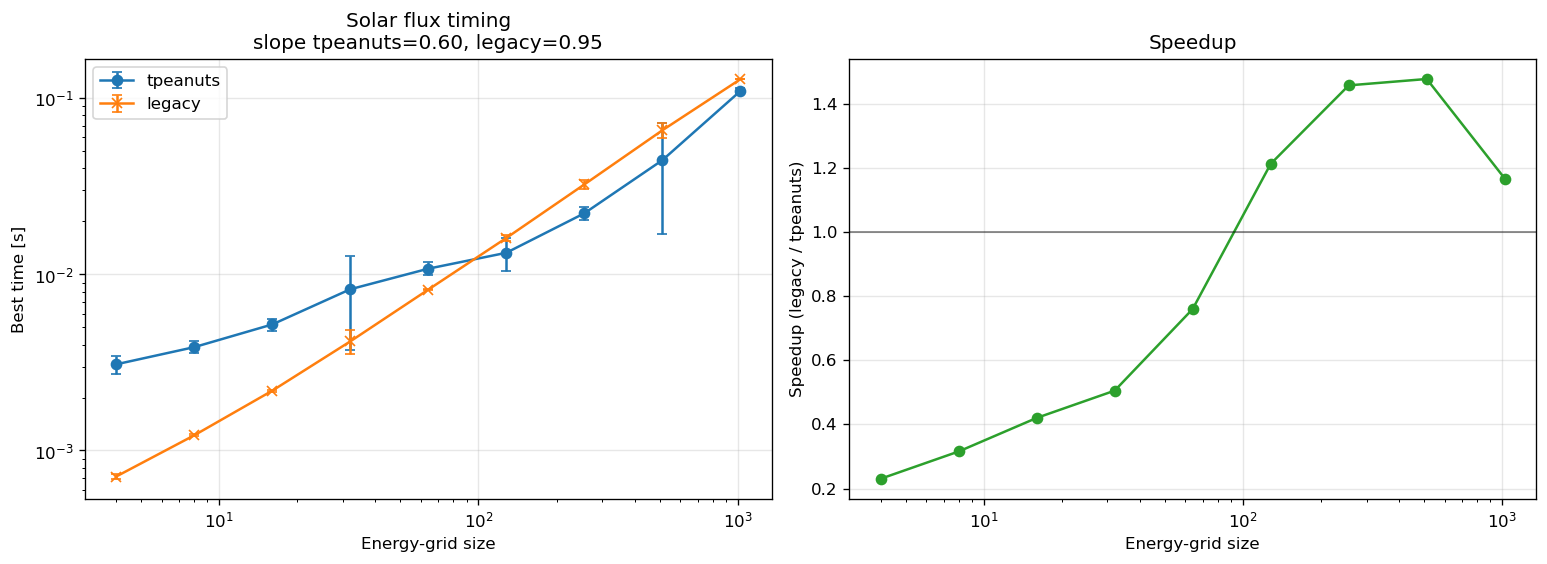

v:\output\benchmark\solar_flux_timing.png


In [9]:
solar_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    spectrum_t = solar_source_spectrum(E)
    spectrum_l = to_numpy(spectrum_t)
    solar_flux_records.append(benchmark_pair(
        "solar flux", ne, None,
        lambda E=E, st=spectrum_t: tpeanuts_solar_mass(E) * st[:, None],
        lambda E=E, sl=spectrum_l: legacy_solar_mass(E) * sl[:, None],
    ))
solar_flux_df = pd.DataFrame(solar_flux_records)
display(solar_flux_df)
save_results(solar_flux_df, "solar_flux_timing")
plot_energy_scaling(solar_flux_df, "Solar flux timing", "solar_flux_timing.png")

## 5. Earth Propagation

This section benchmarks Earth matter propagation over two-dimensional energy-nadir grids. Analytical TPeanuts propagation is batched over the grid, while the legacy reference loops over scalar `Pearth` calls.

**Expected results:** speedup should generally grow with the two-dimensional grid size, especially for analytical Earth propagation.

### 5.1 Probability Timing

The initial state is an incoherent mass-basis weight vector propagated through the Earth density profile.

**Expected results:** the heatmap should show how speedup depends jointly on energy and nadir grid sizes.

earth probabilities                | NE=   4 | Neta=   4 | t=1.6255e-02s±6.9e-04 | leg=1.0915e-03s | x0.07
earth probabilities                | NE=   4 | Neta=   8 | t=1.4744e-02s±1.3e-03 | leg=1.8049e-03s | x0.12
earth probabilities                | NE=   4 | Neta=  16 | t=1.6803e-02s±1.5e-03 | leg=3.2709e-03s | x0.19
earth probabilities                | NE=   4 | Neta=  32 | t=2.1955e-02s±6.6e-04 | leg=6.1863e-03s | x0.28
earth probabilities                | NE=   4 | Neta=  64 | t=2.8752e-02s±4.2e-03 | leg=1.2347e-02s | x0.43
earth probabilities                | NE=   4 | Neta= 128 | t=3.7337e-02s±4.4e-03 | leg=2.4217e-02s | x0.65
earth probabilities                | NE=   4 | Neta= 256 | t=6.8893e-02s±4.7e-03 | leg=4.8345e-02s | x0.70
earth probabilities                | NE=   8 | Neta=   4 | t=1.5011e-02s±1.1e-03 | leg=2.0527e-03s | x0.14
earth probabilities                | NE=   8 | Neta=   8 | t=1.8810e-02s±6.6e-04 | leg=3.4253e-03s | x0.18
earth probabilities                | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,earth probabilities,4,4,0.016255,0.001092,0.016955,0.001239,0.000688,0.000181,0.067149
1,earth probabilities,4,8,0.014744,0.001805,0.017302,0.001865,0.001309,0.000082,0.122416
2,earth probabilities,4,16,0.016803,0.003271,0.019576,0.003336,0.001452,0.000081,0.194661
3,earth probabilities,4,32,0.021955,0.006186,0.022730,0.006330,0.000658,0.000130,0.281769
4,earth probabilities,4,64,0.028752,0.012347,0.033812,0.012828,0.004189,0.000525,0.429438
...,...,...,...,...,...,...,...,...,...,...
58,earth probabilities,1024,16,0.384550,0.797580,0.428310,0.811850,0.072106,0.018489,2.074062
59,earth probabilities,1024,32,0.732732,1.577728,0.766254,1.610567,0.025077,0.051274,2.153212
60,earth probabilities,1024,64,1.380973,3.143819,1.440720,3.161253,0.060152,0.012658,2.276525
61,earth probabilities,1024,128,2.863726,6.310599,2.926921,6.391116,0.060694,0.048515,2.203632


Saved: v:\output\benchmark\earth_probability_timing.csv


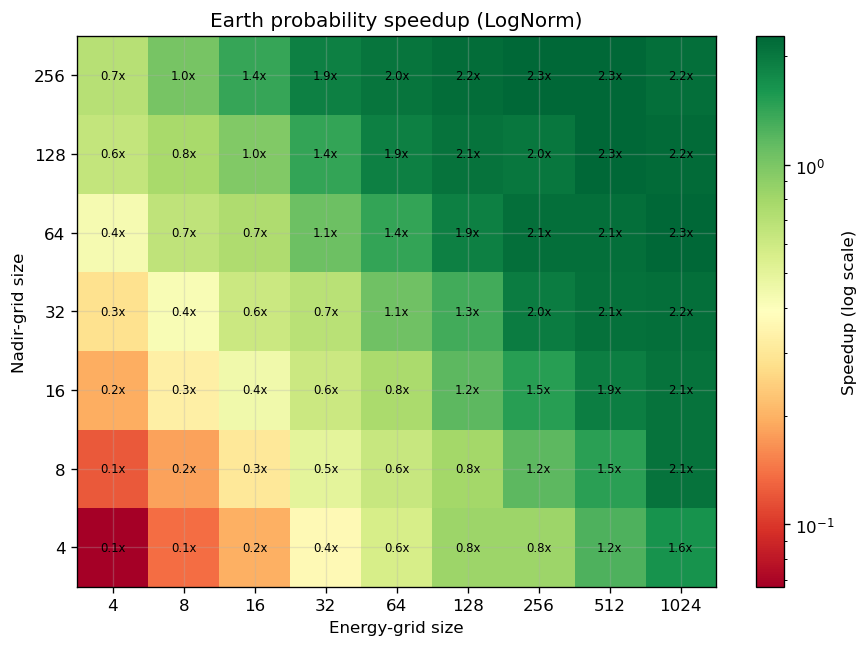

v:\output\benchmark\earth_probability_speedup.png


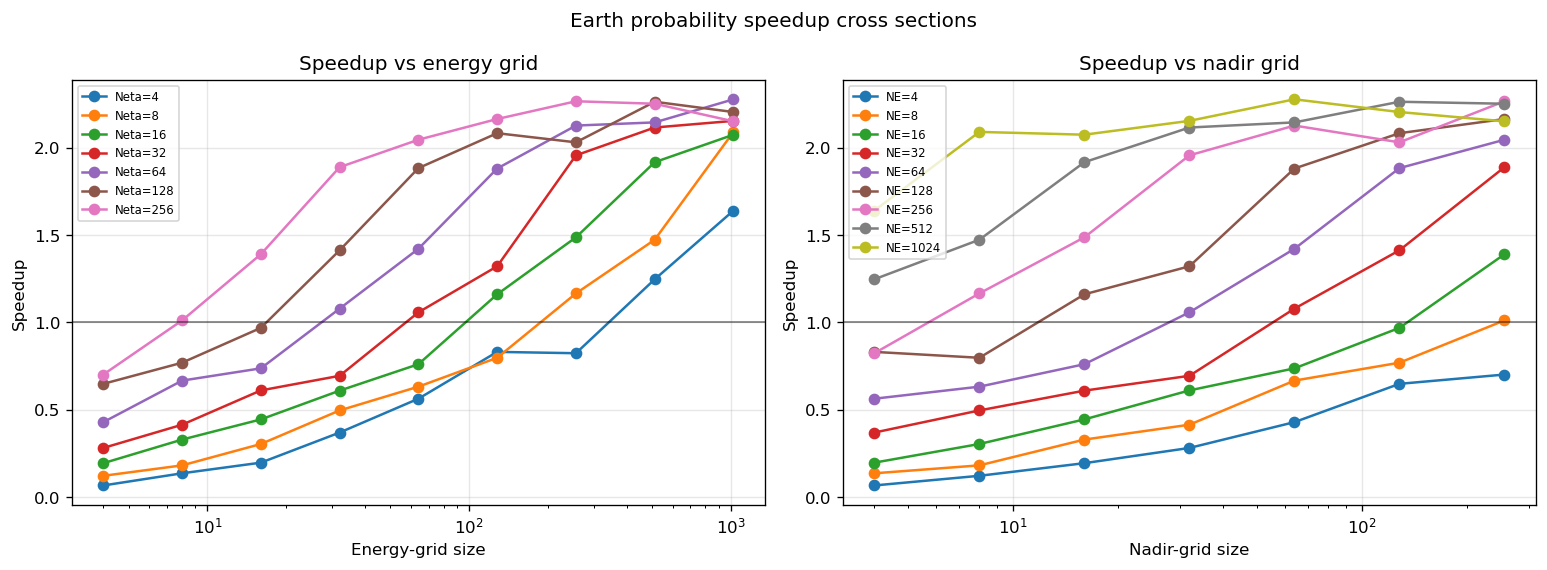

v:\output\benchmark\earth_probability_speedup_cross_sections.png


In [10]:
earth_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        earth_probability_records.append(benchmark_pair(
            "earth probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: torch_pearth_probability(
                MASS_WEIGHTS, E[:, None], eta[None, :], EARTH_DEPTH_M, massbasis=True),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d): np.stack([
                legacy_pearth(MASS_WEIGHTS_NP, earth_density_l, legacy_pmns,
                              DM21_EV2, DM3L_EV2, float(e), float(a),
                              EARTH_DEPTH_M, mode=LEGACY_EARTH_MODE, massbasis=True)
                for e in E_np for a in eta_np
            ]).reshape(len(E_np), len(eta_np), 3),
        ))
earth_probability_df = pd.DataFrame(earth_probability_records)
display(earth_probability_df)
save_results(earth_probability_df, "earth_probability_timing")
plot_heatmap(earth_probability_df, "Earth probability speedup (LogNorm)",
              "earth_probability_speedup.png")
plot_speedup_cross_sections(earth_probability_df, "Earth probability speedup cross sections",
                              "earth_probability_speedup_cross_sections.png")

### 5.2 Flux Timing

This benchmark constructs a mass-to-flavour probability matrix and applies it to a synthetic flux vector.

**Expected results:** the cost should be higher than a single probability-vector call because three basis states are propagated.

earth flux                         | NE=   4 | Neta=   4 | t=4.9079e-02s±4.3e-03 | leg=3.2928e-03s | x0.07
earth flux                         | NE=   4 | Neta=   8 | t=4.7658e-02s±2.8e-03 | leg=5.6270e-03s | x0.12
earth flux                         | NE=   4 | Neta=  16 | t=5.6667e-02s±2.5e-03 | leg=1.0462e-02s | x0.18
earth flux                         | NE=   4 | Neta=  32 | t=6.7554e-02s±3.6e-03 | leg=2.0537e-02s | x0.30
earth flux                         | NE=   4 | Neta=  64 | t=9.2903e-02s±4.1e-03 | leg=4.0278e-02s | x0.43
earth flux                         | NE=   4 | Neta= 128 | t=1.3152e-01s±5.2e-03 | leg=8.1280e-02s | x0.62
earth flux                         | NE=   4 | Neta= 256 | t=2.1482e-01s±3.6e-02 | leg=1.6082e-01s | x0.75
earth flux                         | NE=   8 | Neta=   4 | t=4.6204e-02s±3.5e-03 | leg=6.3697e-03s | x0.14
earth flux                         | NE=   8 | Neta=   8 | t=6.0772e-02s±2.1e-03 | leg=1.0953e-02s | x0.18
earth flux                         | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,earth flux,4,4,0.049079,0.003293,0.053906,0.003398,0.004268,0.000140,0.067093
1,earth flux,4,8,0.047658,0.005627,0.050691,0.005665,0.002835,0.000025,0.118072
2,earth flux,4,16,0.056667,0.010462,0.059612,0.010630,0.002517,0.000098,0.184619
3,earth flux,4,32,0.067554,0.020537,0.072598,0.022932,0.003557,0.003318,0.304013
4,earth flux,4,64,0.092903,0.040278,0.098264,0.040483,0.004089,0.000201,0.433551
...,...,...,...,...,...,...,...,...,...,...
58,earth flux,1024,16,1.221782,2.696038,1.298439,2.771257,0.062667,0.068410,2.206644
59,earth flux,1024,32,2.191075,5.210056,2.324098,5.353162,0.160960,0.100467,2.377853
60,earth flux,1024,64,4.295833,10.553569,4.436915,10.644311,0.172981,0.083787,2.456699
61,earth flux,1024,128,8.766241,20.957576,9.041023,21.576612,0.240820,0.542809,2.390714


Saved: v:\output\benchmark\earth_flux_timing.csv


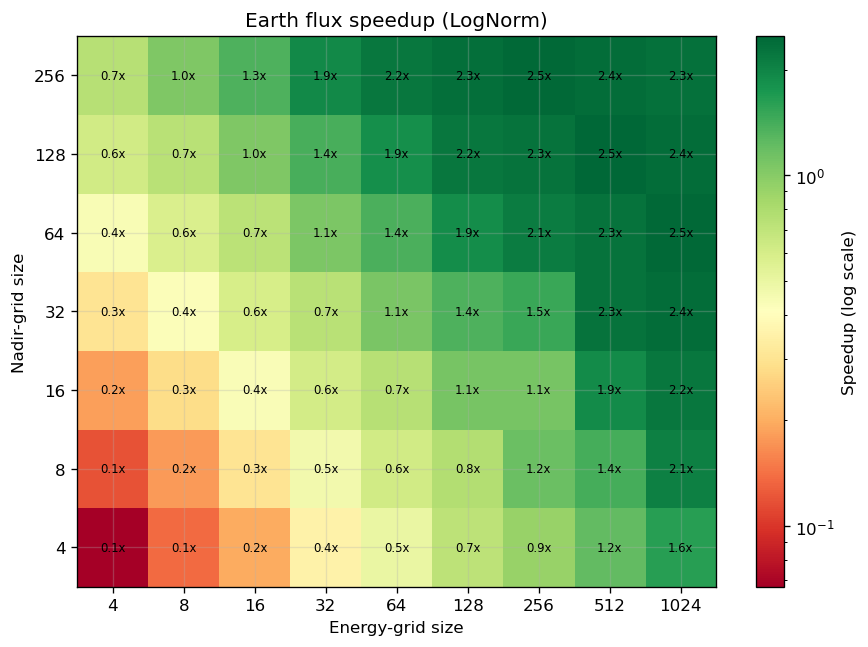

v:\output\benchmark\earth_flux_speedup.png


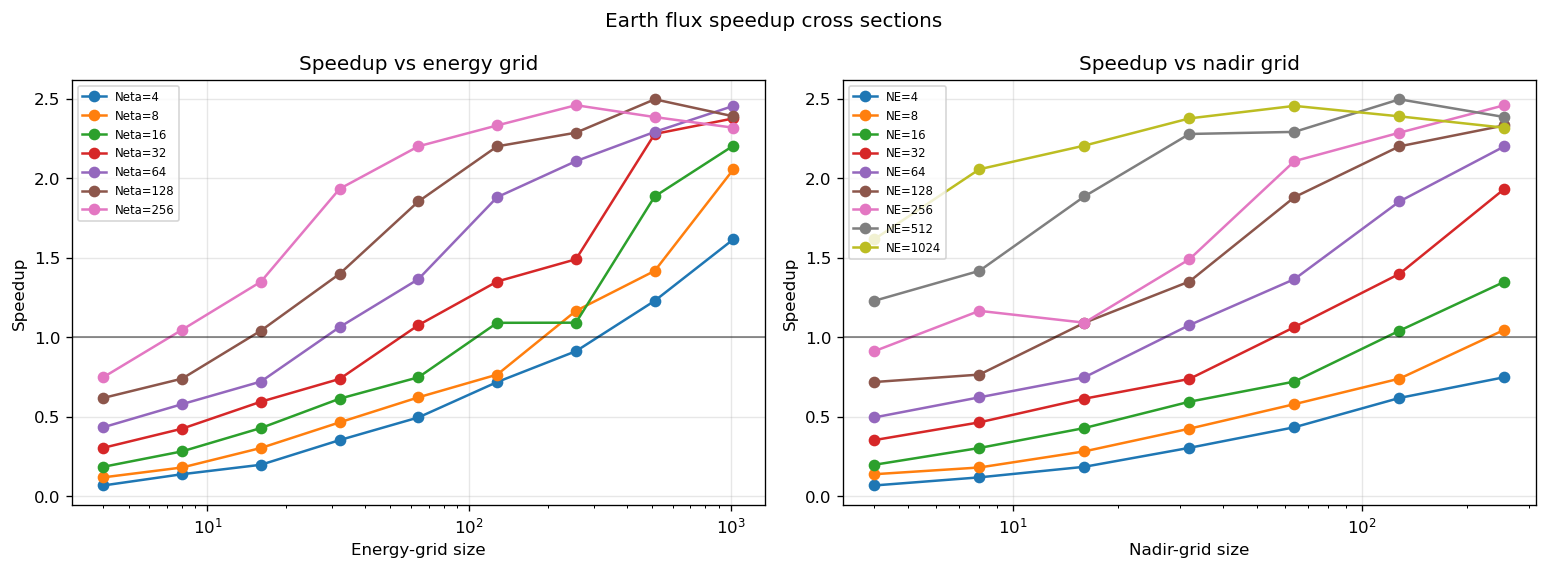

v:\output\benchmark\earth_flux_speedup_cross_sections.png


In [11]:
earth_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        flux   = synthetic_flux(E_1d)
        earth_flux_records.append(benchmark_pair(
            "earth flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, fl=flux: _tpeanuts_earth_flux(E, eta, fl),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d), fl=to_numpy(flux):
                _legacy_earth_flux(E_np, eta_np, fl),
        ))
earth_flux_df = pd.DataFrame(earth_flux_records)
display(earth_flux_df)
save_results(earth_flux_df, "earth_flux_timing")
plot_heatmap(earth_flux_df, "Earth flux speedup (LogNorm)", "earth_flux_speedup.png")
plot_speedup_cross_sections(earth_flux_df, "Earth flux speedup cross sections",
                              "earth_flux_speedup_cross_sections.png")

### 5.3 Analytical vs Numerical Earth Method

This diagnostic compares the perturbative analytical Earth method with the numerical thin-segment method inside TPeanuts.

**Expected results:** analytical propagation should usually be faster than numerical propagation for the configured grid sizes, with the speedup depending on `EARTH_NUMERICAL_STEPS`.

,n_energy,n_nadir,analytical_s,numerical_s,speedup_ana_over_num
0,8,8,0.018191,0.653823,35.942487
1,8,32,0.029323,2.613475,89.126818
2,8,64,0.039296,5.296519,134.786909
3,32,8,0.029856,2.623315,87.865879
4,32,32,0.061603,10.587522,171.865866
5,32,64,0.096374,21.519929,223.295766
6,64,8,0.042204,5.126500,121.468946
7,64,32,0.087341,20.296454,232.382273
8,64,64,0.138209,42.621822,308.386507


Saved: v:\output\benchmark\earth_method_comparison.csv


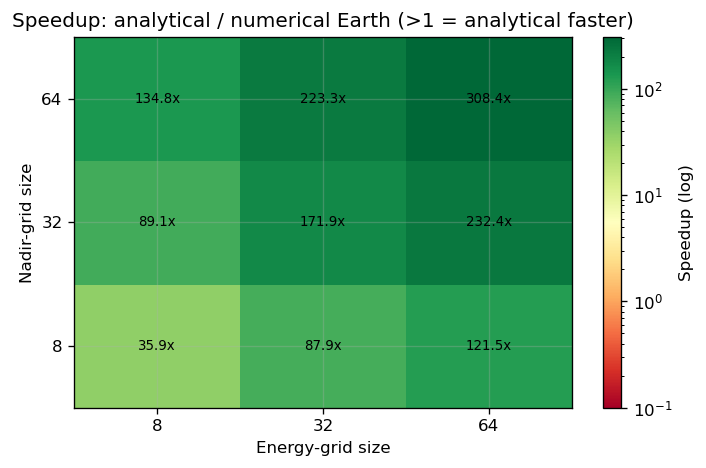

v:\output\benchmark\earth_method_comparison.png


In [12]:
earth_method_records = []
for ne in EARTH_METHOD_COMPARISON_ENERGY_SIZES:
    for neta in EARTH_METHOD_COMPARISON_NADIR_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        t_ana, _, _ = timed_call(lambda E=E_1d, eta=eta_1d: _tpeanuts_pearth_analytical(E, eta))
        t_num, _, _ = timed_call(lambda E=E_1d, eta=eta_1d: _tpeanuts_pearth_numerical(E, eta))
        earth_method_records.append({
            "n_energy": ne, "n_nadir": neta,
            "analytical_s": t_ana, "numerical_s": t_num,
            "speedup_ana_over_num": t_num / max(t_ana, 1e-15),
        })
earth_method_df = pd.DataFrame(earth_method_records)
display(earth_method_df)
save_results(earth_method_df, "earth_method_comparison")

pivot = earth_method_df.pivot(index="n_nadir", columns="n_energy", values="speedup_ana_over_num")
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, origin="lower", aspect="auto",
               norm=mcolors.LogNorm(vmin=0.1, vmax=max(pivot.values.max(), 1.1)), cmap="RdYlGn")
ax.set_xticks(np.arange(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for r in range(pivot.values.shape[0]):
    for c in range(pivot.values.shape[1]):
        ax.text(c, r, f"{pivot.values[r,c]:.1f}x", ha="center", va="center", fontsize=8)
ax.set_xlabel("Energy-grid size"); ax.set_ylabel("Nadir-grid size")
ax.set_title("Speedup: analytical / numerical Earth (>1 = analytical faster)")
fig.colorbar(im, ax=ax, label="Speedup (log)")
fig.tight_layout()
save_and_show("earth_method_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Integrated Probabilities

This section benchmarks a simple nadir-averaged probability, using a uniform exposure weight over the configured nadir grid. It is a timing proxy for exposure-integrated observables.

**Expected results:** timings should combine the Earth grid propagation cost with a small integration overhead.

integrated probabilities           | NE=   4 | Neta=   4 | t=1.9606e-02s±2.4e-03 | leg=2.0768e-03s | x0.11
integrated probabilities           | NE=   4 | Neta=   8 | t=2.0203e-02s±1.8e-03 | leg=2.7953e-03s | x0.14
integrated probabilities           | NE=   4 | Neta=  16 | t=2.1981e-02s±4.7e-03 | leg=4.2542e-03s | x0.19
integrated probabilities           | NE=   4 | Neta=  32 | t=2.4465e-02s±1.9e-03 | leg=7.6109e-03s | x0.31
integrated probabilities           | NE=   4 | Neta=  64 | t=3.5458e-02s±2.6e-03 | leg=1.3459e-02s | x0.38
integrated probabilities           | NE=   4 | Neta= 128 | t=4.6344e-02s±1.7e-03 | leg=2.5755e-02s | x0.56
integrated probabilities           | NE=   4 | Neta= 256 | t=8.1214e-02s±1.5e-03 | leg=4.9715e-02s | x0.61
integrated probabilities           | NE=   8 | Neta=   4 | t=2.2657e-02s±2.4e-03 | leg=3.8641e-03s | x0.17
integrated probabilities           | NE=   8 | Neta=   8 | t=2.4764e-02s±1.5e-03 | leg=5.2222e-03s | x0.21
integrated probabilities           | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,integrated probabilities,4,4,0.019606,0.002077,0.022378,0.002371,0.002398,0.000316,0.105926
1,integrated probabilities,4,8,0.020203,0.002795,0.021786,0.003463,0.001839,0.000756,0.138358
2,integrated probabilities,4,16,0.021981,0.004254,0.026827,0.004769,0.004670,0.000458,0.193538
3,integrated probabilities,4,32,0.024465,0.007611,0.027405,0.007889,0.001892,0.000346,0.311096
4,integrated probabilities,4,64,0.035458,0.013459,0.039043,0.013710,0.002593,0.000173,0.379569
...,...,...,...,...,...,...,...,...,...,...
58,integrated probabilities,1024,16,0.497367,1.059678,0.534233,1.092333,0.035618,0.034505,2.130578
59,integrated probabilities,1024,32,0.881280,1.848634,0.921924,1.874061,0.037701,0.014317,2.097668
60,integrated probabilities,1024,64,1.506413,3.513283,1.521093,3.843289,0.007677,0.243663,2.332218
61,integrated probabilities,1024,128,3.453368,6.903213,7.283081,7.068871,3.134594,0.144031,1.998980


Saved: v:\output\benchmark\integrated_probability_timing.csv


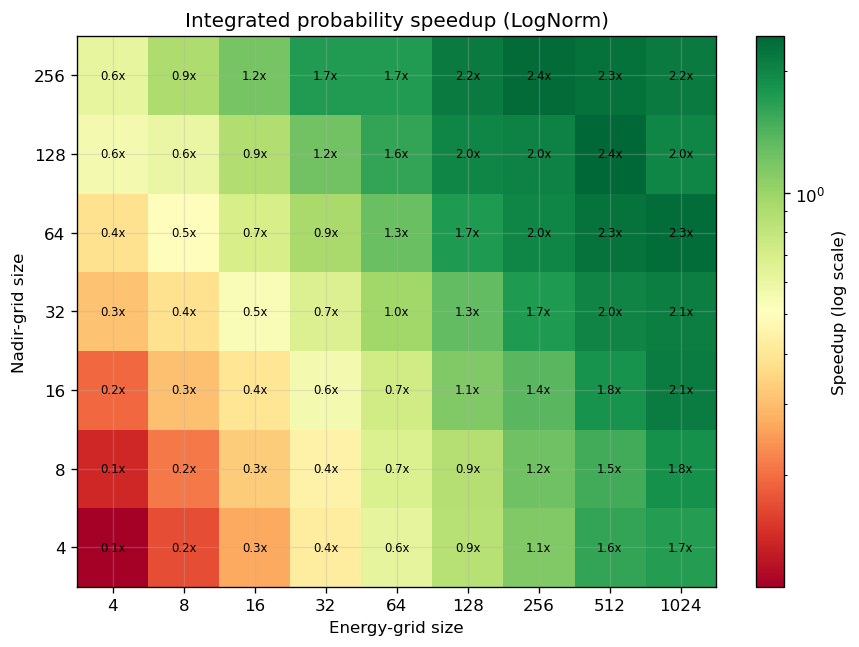

v:\output\benchmark\integrated_probability_speedup.png


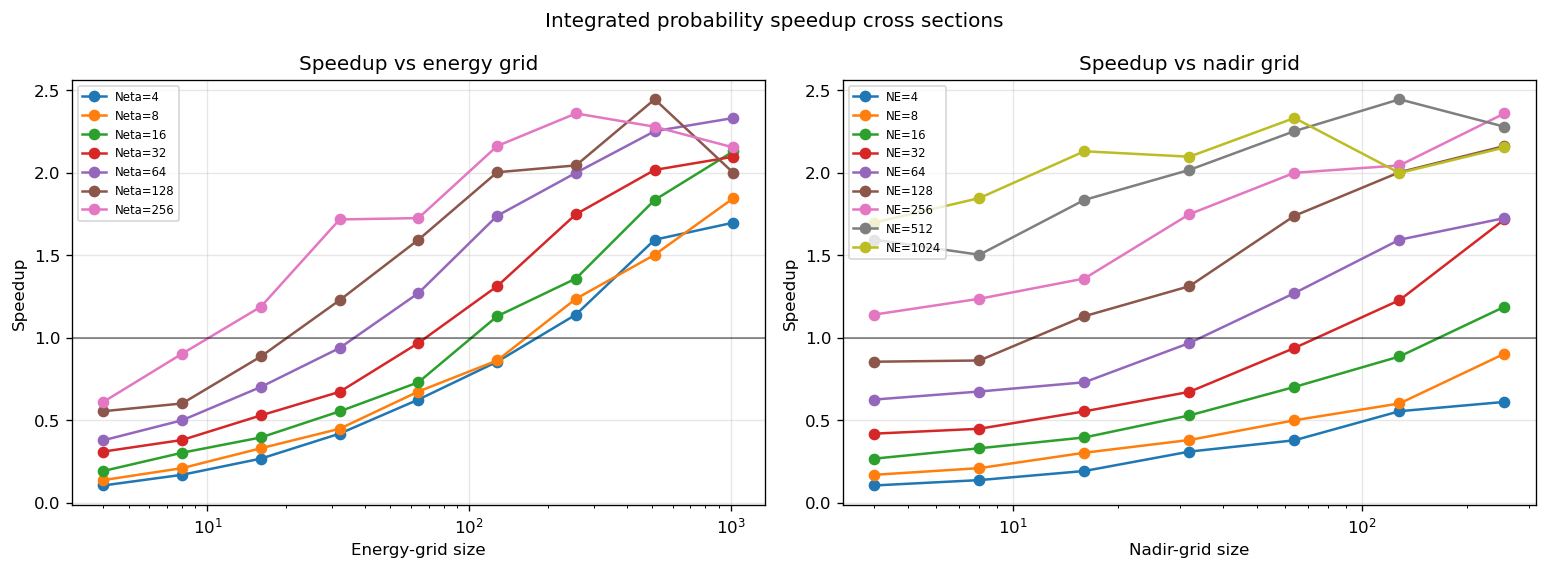

v:\output\benchmark\integrated_probability_speedup_cross_sections.png


In [13]:
integrated_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        integrated_probability_records.append(benchmark_pair(
            "integrated probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, EARTH_DEPTH_M),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d):
                legacy_integrated(E_np, eta_np, EARTH_DEPTH_M),
        ))
integrated_probability_df = pd.DataFrame(integrated_probability_records)
display(integrated_probability_df)
save_results(integrated_probability_df, "integrated_probability_timing")
plot_heatmap(integrated_probability_df, "Integrated probability speedup (LogNorm)",
              "integrated_probability_speedup.png")
plot_speedup_cross_sections(integrated_probability_df, "Integrated probability speedup cross sections",
                              "integrated_probability_speedup_cross_sections.png")

## 7. Solar-to-Detector Chain

This section benchmarks the full incoherent solar-to-detector structure: solar mass-basis production followed by Earth matter propagation at detector nadir angles.

**Expected results:** this is one of the most complete benchmark paths and should show the cumulative benefit of batching the solar and Earth stages.

### 7.1 Probability Timing

The output probability is flavour-resolved at the detector for each energy and nadir angle.

**Expected results:** timing should scale with both the energy and nadir grids.

solar-detector probabilities       | NE=   4 | Neta=   4 | t=2.5532e-02s±1.8e-03 | leg=1.9313e-03s | x0.08
solar-detector probabilities       | NE=   4 | Neta=   8 | t=2.7554e-02s±1.2e-03 | leg=2.6770e-03s | x0.10
solar-detector probabilities       | NE=   4 | Neta=  16 | t=2.9008e-02s±2.7e-03 | leg=4.3469e-03s | x0.15
solar-detector probabilities       | NE=   4 | Neta=  32 | t=3.4969e-02s±2.2e-03 | leg=7.7070e-03s | x0.22
solar-detector probabilities       | NE=   4 | Neta=  64 | t=4.3097e-02s±6.2e-03 | leg=1.4576e-02s | x0.34
solar-detector probabilities       | NE=   4 | Neta= 128 | t=6.1327e-02s±3.1e-03 | leg=2.8520e-02s | x0.47
solar-detector probabilities       | NE=   4 | Neta= 256 | t=9.6230e-02s±9.6e-03 | leg=5.6231e-02s | x0.58
solar-detector probabilities       | NE=   8 | Neta=   4 | t=2.7968e-02s±2.0e-03 | leg=3.6187e-03s | x0.13
solar-detector probabilities       | NE=   8 | Neta=   8 | t=3.1641e-02s±1.2e-03 | leg=5.1468e-03s | x0.16
solar-detector probabilities       | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector probabilities,4,4,0.025532,0.001931,0.027139,0.001965,0.001839,0.000022,0.075642
1,solar-detector probabilities,4,8,0.027554,0.002677,0.028691,0.002724,0.001189,0.000030,0.097156
2,solar-detector probabilities,4,16,0.029008,0.004347,0.031357,0.004402,0.002651,0.000041,0.149853
3,solar-detector probabilities,4,32,0.034969,0.007707,0.037526,0.008012,0.002222,0.000168,0.220395
4,solar-detector probabilities,4,64,0.043097,0.014576,0.047697,0.016900,0.006203,0.002321,0.338217
...,...,...,...,...,...,...,...,...,...,...
58,solar-detector probabilities,1024,16,0.638541,1.091144,0.721325,1.125561,0.071447,0.020043,1.708808
59,solar-detector probabilities,1024,32,1.004840,2.016629,1.016586,2.111507,0.013326,0.070178,2.006915
60,solar-detector probabilities,1024,64,1.870198,3.773073,1.906062,3.922495,0.034566,0.094903,2.017473
61,solar-detector probabilities,1024,128,3.577040,7.439785,3.659014,7.510711,0.053046,0.060766,2.079872


Saved: v:\output\benchmark\solar_detector_probability_timing.csv


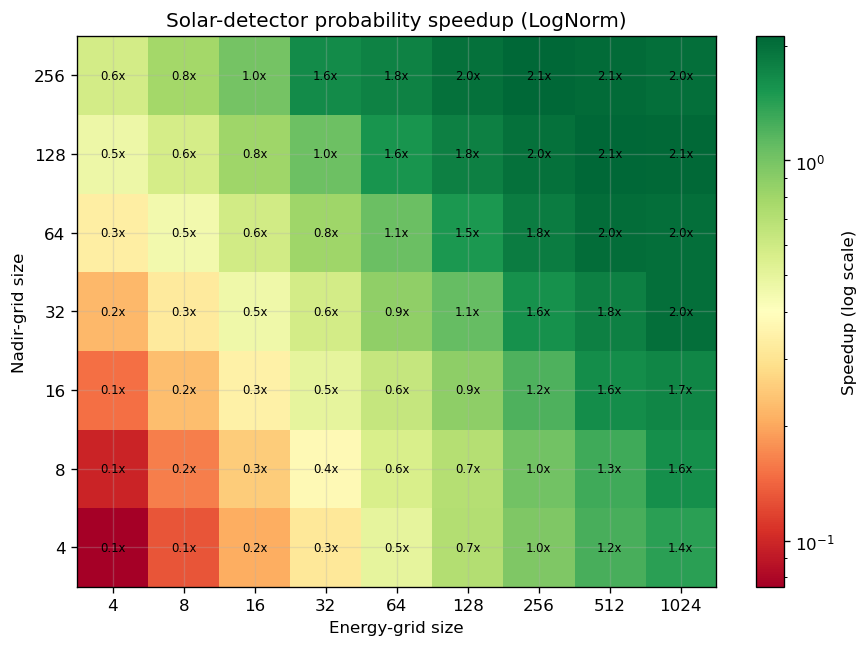

v:\output\benchmark\solar_detector_probability_speedup.png


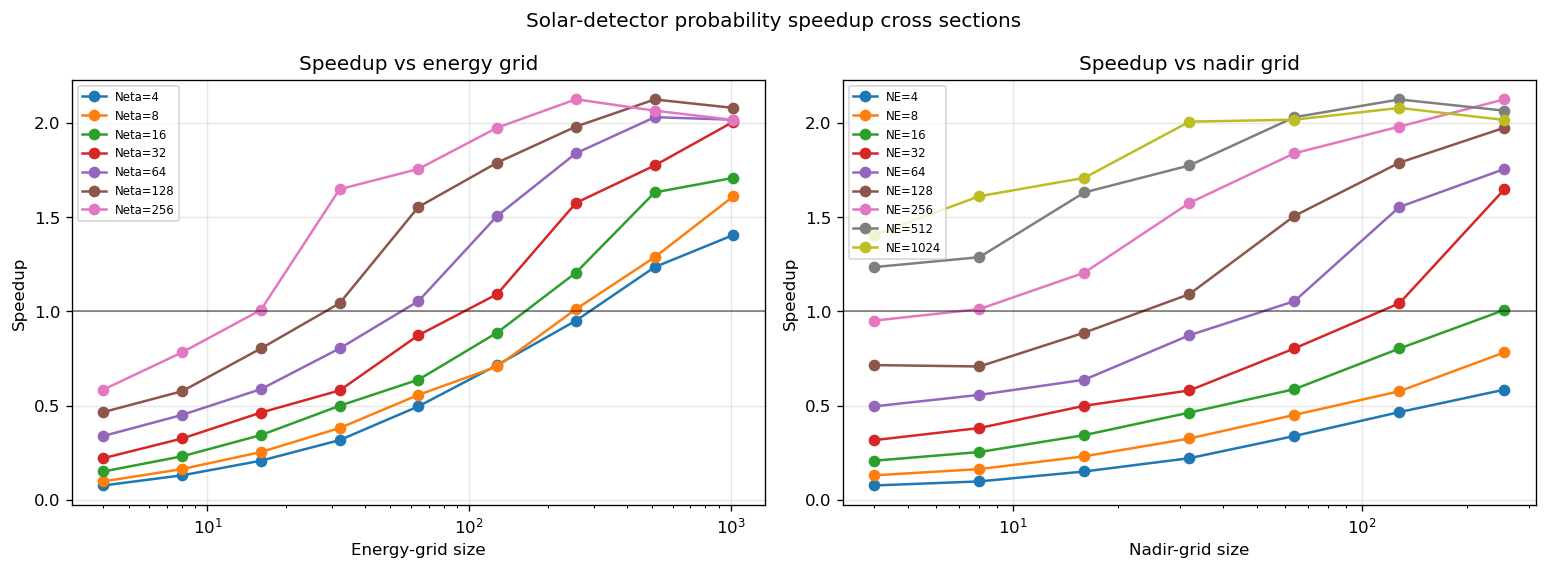

v:\output\benchmark\solar_detector_probability_speedup_cross_sections.png


In [14]:
solar_detector_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        solar_detector_probability_records.append(benchmark_pair(
            "solar-detector probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_solar_detector_probabilities(E, eta),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d):
                legacy_solar_detector_probabilities(E_np, eta_np),
        ))
solar_detector_probability_df = pd.DataFrame(solar_detector_probability_records)
display(solar_detector_probability_df)
save_results(solar_detector_probability_df, "solar_detector_probability_timing")
plot_heatmap(solar_detector_probability_df, "Solar-detector probability speedup (LogNorm)",
              "solar_detector_probability_speedup.png")
plot_speedup_cross_sections(solar_detector_probability_df,
                              "Solar-detector probability speedup cross sections",
                              "solar_detector_probability_speedup_cross_sections.png")

### 7.2 Flux Timing

This benchmark multiplies the detector probability by a synthetic solar-source spectral weight.

**Expected results:** timings should remain close to the probability benchmark because the flux multiplication is elementwise.

solar-detector flux                | NE=   4 | Neta=   4 | t=2.6114e-02s±2.4e-03 | leg=1.9160e-03s | x0.07
solar-detector flux                | NE=   4 | Neta=   8 | t=2.9328e-02s±4.9e-04 | leg=2.7911e-03s | x0.10
solar-detector flux                | NE=   4 | Neta=  16 | t=3.1646e-02s±1.3e-03 | leg=4.3711e-03s | x0.14
solar-detector flux                | NE=   4 | Neta=  32 | t=3.3800e-02s±2.3e-03 | leg=7.6586e-03s | x0.23
solar-detector flux                | NE=   4 | Neta=  64 | t=4.2430e-02s±2.1e-03 | leg=1.4621e-02s | x0.34
solar-detector flux                | NE=   4 | Neta= 128 | t=5.6168e-02s±3.2e-03 | leg=2.8420e-02s | x0.51
solar-detector flux                | NE=   4 | Neta= 256 | t=9.0710e-02s±3.5e-03 | leg=5.6388e-02s | x0.62
solar-detector flux                | NE=   8 | Neta=   4 | t=2.9056e-02s±1.1e-03 | leg=3.6846e-03s | x0.13
solar-detector flux                | NE=   8 | Neta=   8 | t=3.0816e-02s±2.7e-03 | leg=5.4510e-03s | x0.18
solar-detector flux                | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector flux,4,4,0.026114,0.001916,0.028417,0.002086,0.002442,0.000167,0.073370
1,solar-detector flux,4,8,0.029328,0.002791,0.030050,0.002936,0.000494,0.000174,0.095167
2,solar-detector flux,4,16,0.031646,0.004371,0.032746,0.004473,0.001263,0.000073,0.138124
3,solar-detector flux,4,32,0.033800,0.007659,0.037460,0.008450,0.002264,0.001192,0.226583
4,solar-detector flux,4,64,0.042430,0.014621,0.044650,0.015083,0.002134,0.000457,0.344582
...,...,...,...,...,...,...,...,...,...,...
58,solar-detector flux,1024,16,0.589239,1.081570,0.597538,1.097206,0.009893,0.011585,1.835536
59,solar-detector flux,1024,32,0.985480,1.972070,1.012262,2.007197,0.024870,0.046923,2.001127
60,solar-detector flux,1024,64,1.794330,3.757706,1.809969,3.772167,0.009000,0.009704,2.094212
61,solar-detector flux,1024,128,3.509807,7.330925,3.544643,7.354272,0.031847,0.014731,2.088697


Saved: v:\output\benchmark\solar_detector_flux_timing.csv


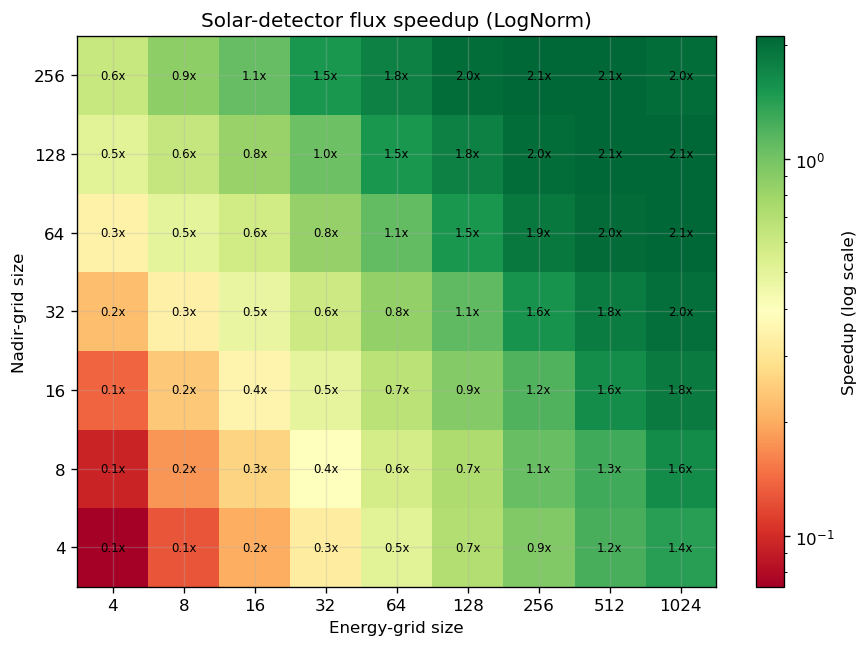

v:\output\benchmark\solar_detector_flux_speedup.png


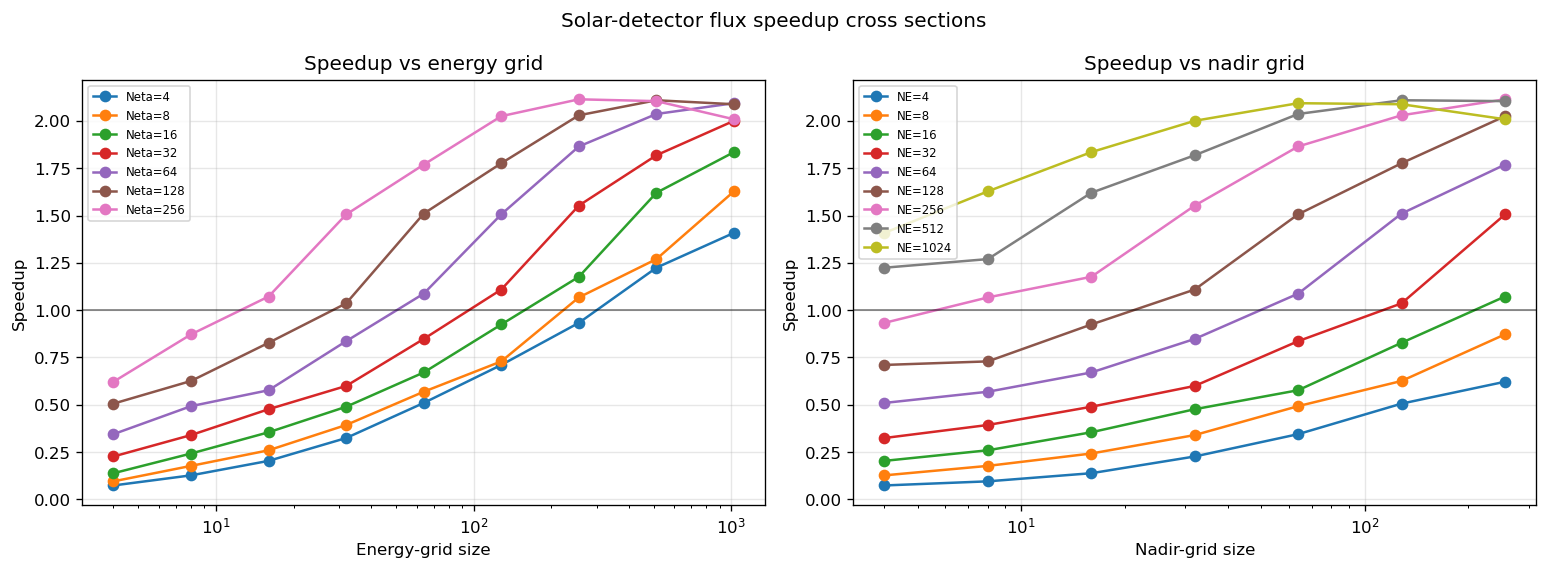

v:\output\benchmark\solar_detector_flux_speedup_cross_sections.png


In [15]:
solar_detector_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d      = energy_grid(ne, solar=True)
        eta_1d    = nadir_grid(neta)
        spectrum_t = solar_source_spectrum(E_1d)
        spectrum_l = to_numpy(spectrum_t)
        solar_detector_flux_records.append(benchmark_pair(
            "solar-detector flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, st=spectrum_t:
                tpeanuts_solar_detector_probabilities(E, eta) * st[:, None, None],
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d), sl=spectrum_l:
                legacy_solar_detector_probabilities(E_np, eta_np) * sl[:, None, None],
        ))
solar_detector_flux_df = pd.DataFrame(solar_detector_flux_records)
display(solar_detector_flux_df)
save_results(solar_detector_flux_df, "solar_detector_flux_timing")
plot_heatmap(solar_detector_flux_df, "Solar-detector flux speedup (LogNorm)",
              "solar_detector_flux_speedup.png")
plot_speedup_cross_sections(solar_detector_flux_df,
                              "Solar-detector flux speedup cross sections",
                              "solar_detector_flux_speedup_cross_sections.png")

### 7.3 Integrated Probability Timing

This benchmark integrates the solar-to-detector probability over a uniform nadir-angle exposure. It exercises the same solar production and Earth propagation chain, plus the final angular contraction.

**Expected results:** timings should increase with both energy and nadir grid size. The speedup map should show whether tensor batching compensates for the extra integration step.

solar-detector integrated          | NE=   4 | Neta=   4 | t=2.6542e-02s±6.3e-04 | leg=2.2298e-03s | x0.08
solar-detector integrated          | NE=   4 | Neta=   8 | t=2.8377e-02s±1.0e-03 | leg=2.9800e-03s | x0.11
solar-detector integrated          | NE=   4 | Neta=  16 | t=3.1434e-02s±1.5e-03 | leg=4.5602e-03s | x0.15
solar-detector integrated          | NE=   4 | Neta=  32 | t=3.3639e-02s±1.3e-03 | leg=7.9544e-03s | x0.24
solar-detector integrated          | NE=   4 | Neta=  64 | t=4.4070e-02s±1.4e-03 | leg=1.4855e-02s | x0.34
solar-detector integrated          | NE=   4 | Neta= 128 | t=6.1048e-02s±2.0e-03 | leg=2.9100e-02s | x0.48
solar-detector integrated          | NE=   4 | Neta= 256 | t=8.8241e-02s±3.3e-03 | leg=5.6517e-02s | x0.64
solar-detector integrated          | NE=   8 | Neta=   4 | t=3.0238e-02s±6.6e-04 | leg=3.9850e-03s | x0.13
solar-detector integrated          | NE=   8 | Neta=   8 | t=3.2595e-02s±6.4e-04 | leg=5.5789e-03s | x0.17
solar-detector integrated          | 

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector integrated,4,4,0.026542,0.002230,0.027551,0.002324,0.000630,0.000101,0.084010
1,solar-detector integrated,4,8,0.028377,0.002980,0.030328,0.003043,0.001024,0.000073,0.105014
2,solar-detector integrated,4,16,0.031434,0.004560,0.033965,0.004643,0.001518,0.000088,0.145074
3,solar-detector integrated,4,32,0.033639,0.007954,0.035856,0.008952,0.001327,0.001234,0.236466
4,solar-detector integrated,4,64,0.044070,0.014855,0.046559,0.015294,0.001395,0.000320,0.337069
...,...,...,...,...,...,...,...,...,...,...
58,solar-detector integrated,1024,16,0.603071,1.133822,0.609614,1.146954,0.010129,0.012396,1.880081
59,solar-detector integrated,1024,32,0.998754,2.020641,1.009350,2.047042,0.012400,0.019068,2.023162
60,solar-detector integrated,1024,64,1.773370,3.802431,1.795219,3.835702,0.011906,0.022820,2.144184
61,solar-detector integrated,1024,128,3.466777,7.408988,3.548309,7.443094,0.054346,0.030359,2.137140


Saved: v:\output\benchmark\solar_detector_integrated_timing.csv


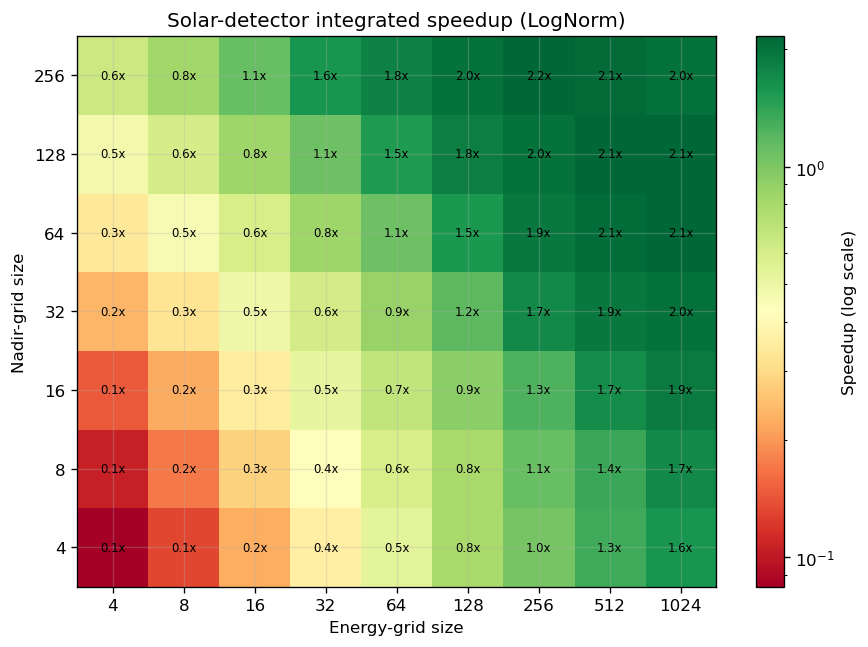

v:\output\benchmark\solar_detector_integrated_speedup.png


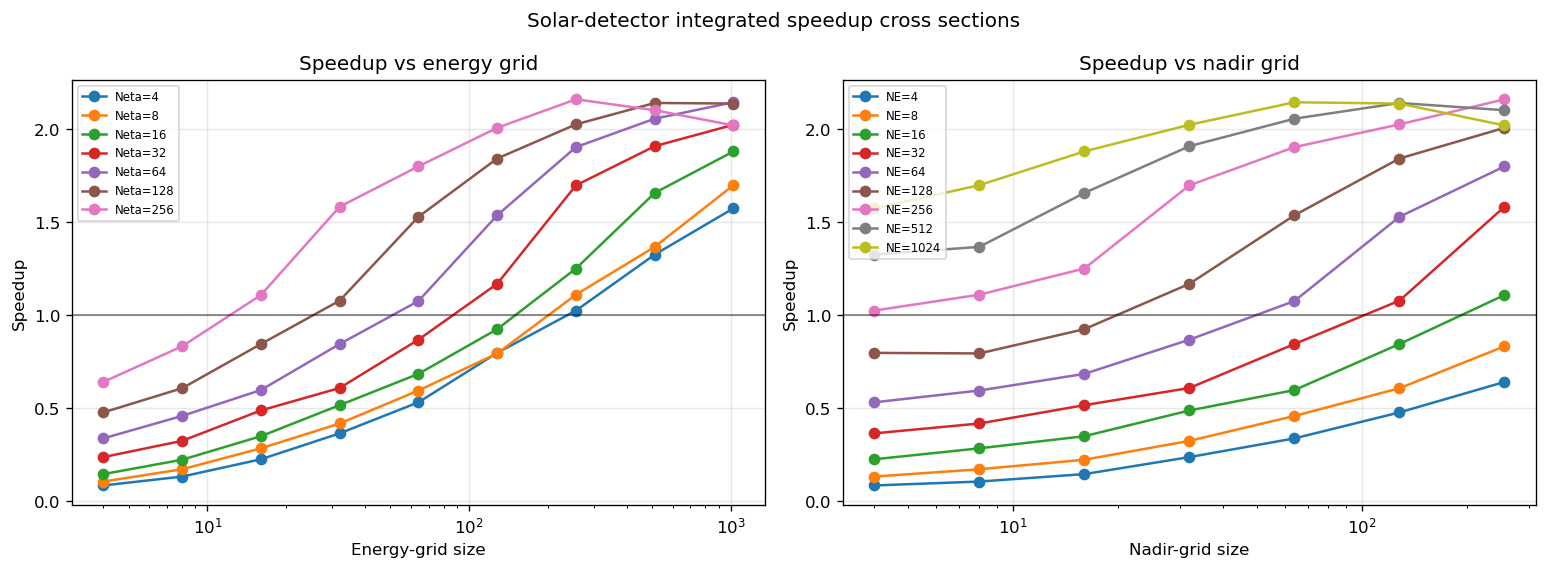

v:\output\benchmark\solar_detector_integrated_speedup_cross_sections.png


In [16]:
solar_detector_integrated_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d   = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        solar_detector_integrated_records.append(benchmark_pair(
            "solar-detector integrated", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, SOLAR_DETECTOR_DEPTH_M),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d):
                legacy_integrated(E_np, eta_np, SOLAR_DETECTOR_DEPTH_M),
        ))
solar_detector_integrated_df = pd.DataFrame(solar_detector_integrated_records)
display(solar_detector_integrated_df)
save_results(solar_detector_integrated_df, "solar_detector_integrated_timing")
plot_heatmap(solar_detector_integrated_df,
              "Solar-detector integrated speedup (LogNorm)",
              "solar_detector_integrated_speedup.png")
plot_speedup_cross_sections(solar_detector_integrated_df,
                              "Solar-detector integrated speedup cross sections",
                              "solar_detector_integrated_speedup_cross_sections.png")

## 8. GPU Benchmark (Conditional)

This optional benchmark runs only when a CUDA device is available. It compares CPU and GPU execution for the solar-to-detector probability stage using the same physical inputs and grid sizes.

**Expected results:** on machines without CUDA the cell should skip cleanly. When CUDA is available, the GPU speedup should become more meaningful for larger energy and nadir grids, where transfer overhead is less dominant.

GPU: NVIDIA GeForce GTX 1080 Ti
NE=   4 | Neta=   4 | CPU=2.6550e-02s | GPU=7.8454e-02s | x0.34
NE=   4 | Neta=   8 | CPU=2.5584e-02s | GPU=8.0161e-02s | x0.32
NE=   4 | Neta=  16 | CPU=3.0622e-02s | GPU=7.7583e-02s | x0.39
NE=   4 | Neta=  32 | CPU=3.1542e-02s | GPU=7.7963e-02s | x0.40
NE=   4 | Neta=  64 | CPU=4.2800e-02s | GPU=8.4778e-02s | x0.50
NE=   4 | Neta= 128 | CPU=5.9660e-02s | GPU=8.4209e-02s | x0.71
NE=   4 | Neta= 256 | CPU=8.6860e-02s | GPU=8.5660e-02s | x1.01
NE=   8 | Neta=   4 | CPU=2.9374e-02s | GPU=7.5568e-02s | x0.39
NE=   8 | Neta=   8 | CPU=3.1765e-02s | GPU=7.8539e-02s | x0.40
NE=   8 | Neta=  16 | CPU=3.6214e-02s | GPU=7.3938e-02s | x0.49
NE=   8 | Neta=  32 | CPU=4.6259e-02s | GPU=8.1369e-02s | x0.57
NE=   8 | Neta=  64 | CPU=6.2572e-02s | GPU=8.1488e-02s | x0.77
NE=   8 | Neta= 128 | CPU=9.6598e-02s | GPU=8.3174e-02s | x1.16
NE=   8 | Neta= 256 | CPU=1.3500e-01s | GPU=1.0423e-01s | x1.30
NE=  16 | Neta=   4 | CPU=3.3372e-02s | GPU=7.6586e-02s | x0.44
NE=  16 

,n_energy,n_nadir,cpu_s,gpu_s,speedup_gpu_over_cpu
0,4,4,0.026550,0.078454,0.338415
1,4,8,0.025584,0.080161,0.319161
2,4,16,0.030622,0.077583,0.394708
3,4,32,0.031542,0.077963,0.404578
4,4,64,0.042800,0.084778,0.504849
...,...,...,...,...,...
58,1024,16,0.595208,0.755891,0.787425
59,1024,32,1.003597,3.533552,0.284019
60,1024,64,1.774035,12.830141,0.138271
61,1024,128,3.460402,24.113439,0.143505


Saved: v:\output\benchmark\gpu_timing.csv


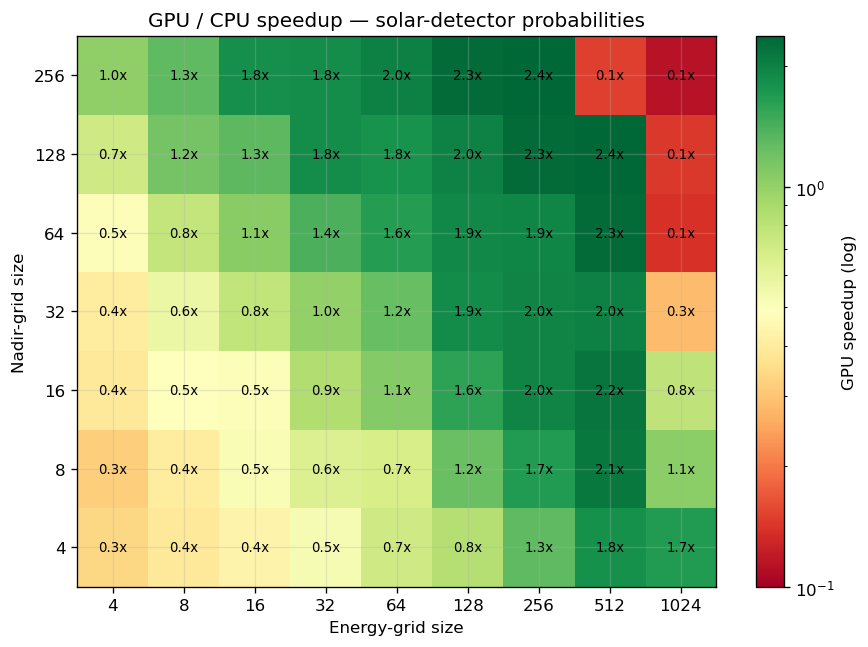

v:\output\benchmark\gpu_speedup_heatmap.png


In [17]:
if not torch.cuda.is_available():
    print("No CUDA device — skipping GPU benchmark.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    _ = torch.zeros(1, device=GPU_DEVICE)
    torch.cuda.synchronize()

    gpu_records = []
    for ne in ENERGY_GRID_SIZES:
        for neta in NADIR_GRID_SIZES:
            E_1d   = energy_grid(ne, solar=True)
            eta_1d = nadir_grid(neta)

            def tpeanuts_cpu():
                return tpeanuts_solar_detector_probabilities(E_1d, eta_1d, device=DEVICE)

            def tpeanuts_gpu():
                E_g   = E_1d.to(GPU_DEVICE)
                eta_g = eta_1d.to(GPU_DEVICE)
                result = tpeanuts_solar_detector_probabilities(E_g, eta_g, device=GPU_DEVICE)
                torch.cuda.synchronize()
                return result

            t_cpu, _, _ = timed_call(tpeanuts_cpu)
            t_gpu, _, _ = timed_call(tpeanuts_gpu)
            speedup_gpu = t_cpu / max(t_gpu, 1e-15)
            gpu_records.append({
                "n_energy": ne, "n_nadir": neta,
                "cpu_s": t_cpu, "gpu_s": t_gpu,
                "speedup_gpu_over_cpu": speedup_gpu,
            })
            print(f"NE={ne:4d} | Neta={neta:4d} | CPU={t_cpu:.4e}s | GPU={t_gpu:.4e}s | x{speedup_gpu:.2f}")

    gpu_df = pd.DataFrame(gpu_records)
    display(gpu_df)
    save_results(gpu_df, "gpu_timing")

    pivot_gpu = gpu_df.pivot(index="n_nadir", columns="n_energy", values="speedup_gpu_over_cpu")
    vmax_gpu  = max(pivot_gpu.values.max(), 1.1)
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    im = ax.imshow(pivot_gpu.values, origin="lower", aspect="auto",
                   norm=mcolors.LogNorm(vmin=0.1, vmax=vmax_gpu), cmap="RdYlGn")
    ax.set_xticks(np.arange(len(pivot_gpu.columns))); ax.set_xticklabels(pivot_gpu.columns)
    ax.set_yticks(np.arange(len(pivot_gpu.index)));   ax.set_yticklabels(pivot_gpu.index)
    for r in range(pivot_gpu.values.shape[0]):
        for c in range(pivot_gpu.values.shape[1]):
            ax.text(c, r, f"{pivot_gpu.values[r,c]:.1f}x", ha="center", va="center", fontsize=8)
    ax.set_xlabel("Energy-grid size"); ax.set_ylabel("Nadir-grid size")
    ax.set_title("GPU / CPU speedup — solar-detector probabilities")
    fig.colorbar(im, ax=ax, label="GPU speedup (log)")
    fig.tight_layout()
    save_and_show("gpu_speedup_heatmap.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 9. Summary

The summary combines all benchmark tables, stores a global CSV file, and produces aggregate speedup figures for the largest grid sizes. It is the final comparison layer for identifying where the torch-native implementation is faster or slower than the legacy reference.

**Expected results:** the median-speedup plot should make the dominant performance regimes visible, while the largest-grid comparison should summarize absolute timing and relative speedup for the most demanding benchmark points.

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum probabilities,4,None,0.001265,0.000765,0.001323,0.000792,0.000059,0.000028,0.604710
1,vacuum probabilities,8,None,0.001246,0.001294,0.001421,0.001312,0.000167,0.000012,1.038202
2,vacuum probabilities,16,None,0.001260,0.002335,0.001364,0.002376,0.000109,0.000026,1.852643
3,vacuum probabilities,32,None,0.001277,0.004472,0.001333,0.005024,0.000080,0.000429,3.503212
4,vacuum probabilities,64,None,0.001316,0.008599,0.001640,0.008790,0.000369,0.000218,6.533774
...,...,...,...,...,...,...,...,...,...,...
409,solar-detector integrated,1024,16,0.603071,1.133822,0.609614,1.146954,0.010129,0.012396,1.880081
410,solar-detector integrated,1024,32,0.998754,2.020641,1.009350,2.047042,0.012400,0.019068,2.023162
411,solar-detector integrated,1024,64,1.773370,3.802431,1.795219,3.835702,0.011906,0.022820,2.144184
412,solar-detector integrated,1024,128,3.466777,7.408988,3.548309,7.443094,0.054346,0.030359,2.137140


Saved: v:\output\benchmark\all_performance_timing.csv


,section,median_speedup,min_speedup,max_speedup
9,vacuum probabilities,6.533774,0.604710,61.809021
8,vacuum flux,5.897761,0.562131,60.357763
2,integrated probabilities,1.131195,0.105926,2.445381
1,earth probabilities,1.078920,0.067149,2.276525
0,earth flux,1.076581,0.067093,2.498062
5,solar-detector flux,0.924383,0.073370,2.114769
6,solar-detector integrated,0.924292,0.084010,2.160029
7,solar-detector probabilities,0.887020,0.075642,2.125623
4,solar probabilities,0.800436,0.201242,1.713151
3,solar flux,0.760410,0.230450,1.478360


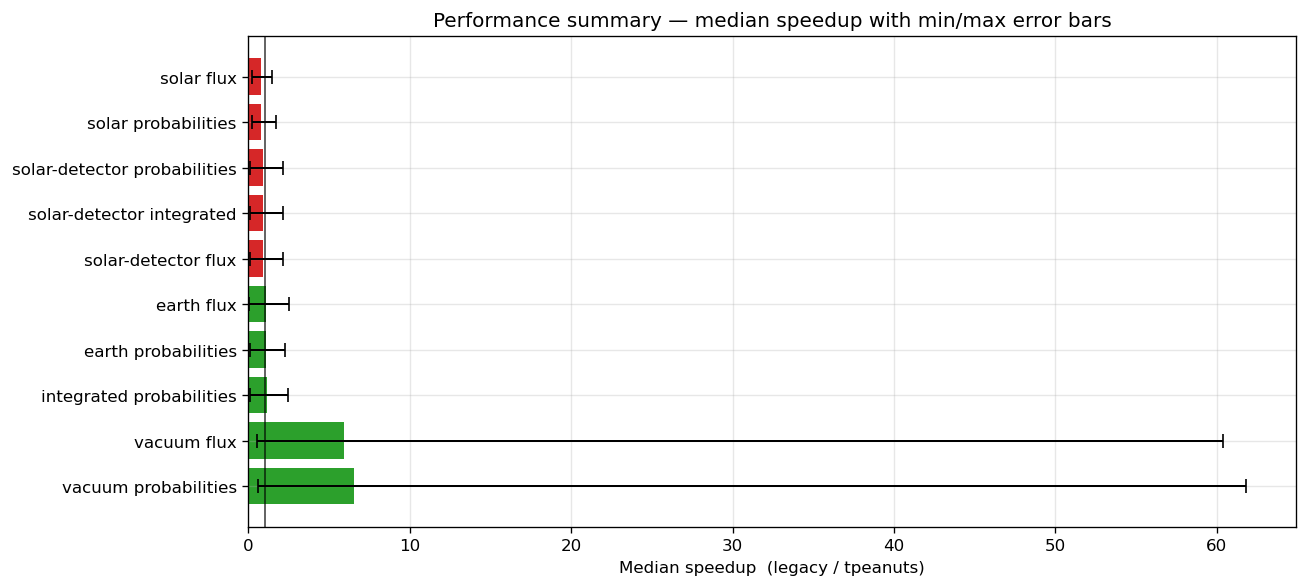

v:\output\benchmark\summary_median_speedup.png


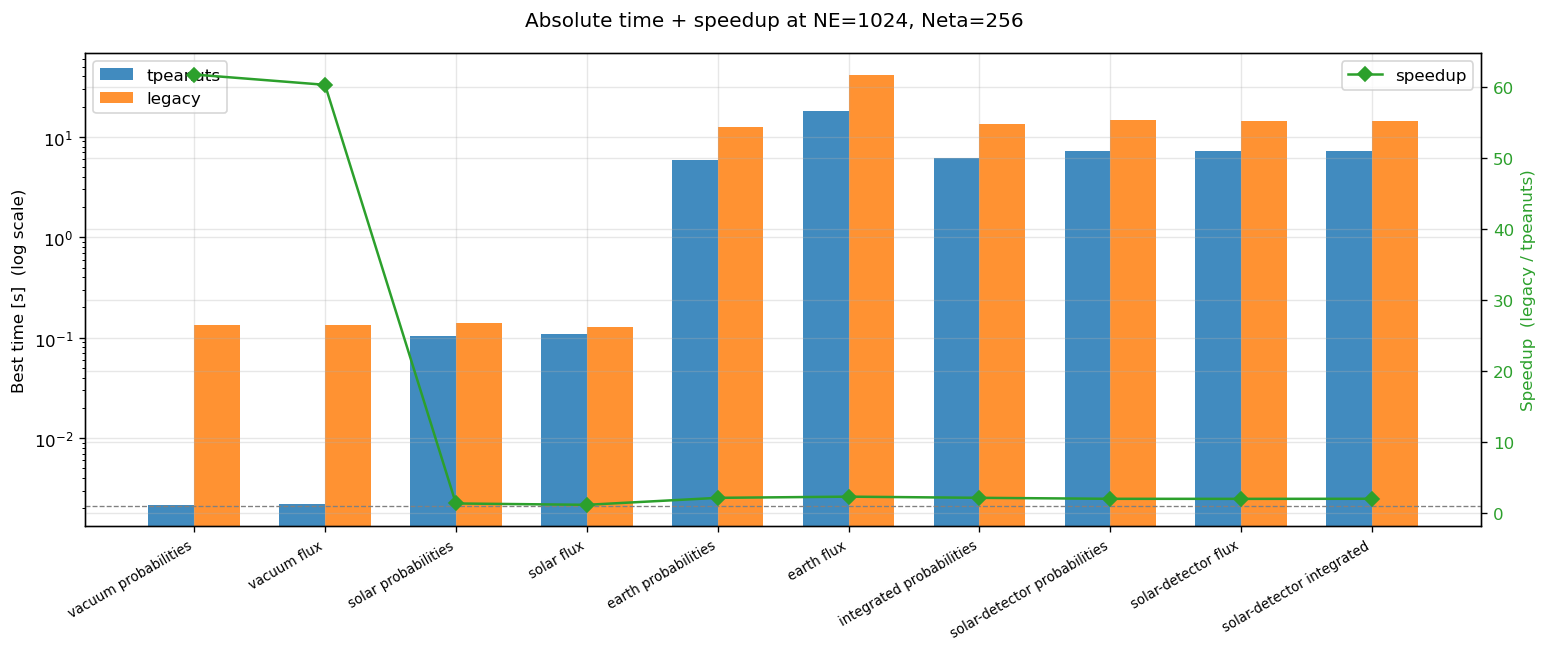

v:\output\benchmark\summary_time_and_speedup.png


In [18]:
all_timing_df = pd.concat([
    vacuum_probability_df, vacuum_flux_df,
    solar_probability_df,  solar_flux_df,
    earth_probability_df,  earth_flux_df,
    integrated_probability_df,
    solar_detector_probability_df, solar_detector_flux_df,
    solar_detector_integrated_df,
], ignore_index=True)
display(all_timing_df)
save_results(all_timing_df, "all_performance_timing")

summary = (
    all_timing_df.groupby("section", as_index=False)
    .agg(
        median_speedup=("speedup_legacy_over_tpeanuts", "median"),
        min_speedup   =("speedup_legacy_over_tpeanuts", "min"),
        max_speedup   =("speedup_legacy_over_tpeanuts", "max"),
    )
    .sort_values("median_speedup", ascending=False)
)
display(summary)

fig, ax = plt.subplots(figsize=(11, 5.0))
xerr = np.array([
    summary["median_speedup"] - summary["min_speedup"],
    summary["max_speedup"]    - summary["median_speedup"],
])
colors = ["C2" if v > 1.0 else "C3" for v in summary["median_speedup"]]
ax.barh(summary["section"], summary["median_speedup"], xerr=xerr,
        color=colors, error_kw={"capsize": 4, "elinewidth": 1.2})
ax.axvline(1.0, color="black", lw=1.2, alpha=0.6)
ax.set_xlabel("Median speedup  (legacy / tpeanuts)")
ax.set_title("Performance summary — median speedup with min/max error bars")
fig.tight_layout()
save_and_show("summary_median_speedup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

largest_ne   = max(ENERGY_GRID_SIZES)
largest_neta = max(NADIR_GRID_SIZES)

large_rows = []
for df in [vacuum_probability_df, vacuum_flux_df, solar_probability_df, solar_flux_df,
           earth_probability_df, earth_flux_df, integrated_probability_df,
           solar_detector_probability_df, solar_detector_flux_df, solar_detector_integrated_df]:
    row = get_largest_timing_row(df, largest_ne, largest_neta)
    if row is not None:
        large_rows.append(row)
large_df = pd.DataFrame(large_rows).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
x    = np.arange(len(large_df))
w    = 0.35
ax1.bar(x - w/2, large_df["tpeanuts_best_s"], width=w, label="tpeanuts", color="C0", alpha=0.85)
ax1.bar(x + w/2, large_df["legacy_best_s"],   width=w, label="legacy",   color="C1", alpha=0.85)
ax1.set_yscale("log")
ax1.set_ylabel("Best time [s]  (log scale)")
ax1.set_xticks(x)
ax1.set_xticklabels(large_df["section"], rotation=30, ha="right", fontsize=8)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, large_df["speedup_legacy_over_tpeanuts"], "D-", color="C2", label="speedup", zorder=5)
ax2.axhline(1.0, color="gray", lw=0.8, ls="--")
ax2.set_ylabel("Speedup  (legacy / tpeanuts)", color="C2")
ax2.tick_params(axis="y", labelcolor="C2")
ax2.legend(loc="upper right")

fig.suptitle(f"Absolute time + speedup at NE={largest_ne}, Neta={largest_neta}")
fig.tight_layout()
save_and_show("summary_time_and_speedup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)